# Multi-Layer Yield Curve Network Analysis

Merged notebook: **Chapters A–G** from `ycs_multilayer_evolution.ipynb`, continued by **Chapters H–O** from `ycs_multilayer_enhanced.ipynb`. The source notebooks are unchanged.

Each layer is a maturity term (6M, 1Y, 2Y, 5Y, …); nodes are bond issuers. Inter-layer edges connect the same issuer across terms.

## Key Concepts
- **Intra-layer edges**: Correlations between issuers within the same term
- **Inter-layer edges**: Direct connections linking the same issuer across terms
- **Temporal evolution**: Rolling window networks over time for each layer + aggregate multi-layer structure
- **Multi-layer metrics**: Degree centrality, clustering, betweenness accounting for all layers

## Enhanced extensions (Part II)
- Yield curve factor extraction (Nelson-Siegel + PCA)
- Residual-based network construction
- Weighted inter-layer connectivity
- Temporal factor dynamics & regime classification
- Multi-layer community detection with layer awareness
- Stress testing & correlation breakdown detection
- Advanced centrality (tensor-based, spreading dynamics)
- 3D interactive visualization
- Signal subgraph detection

## Contents
1. **Part I** — Multi-layer network evolution (Chapters A–G)
2. **Part II** — Factor models, residuals, and stress (Chapters H–O)
3. **Part III** — Roadmaps and suggestions (from both notebooks)


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import polars as pl
import networkx as nx
from pathlib import Path
import duckdb
from tqdm import tqdm
from datetime import datetime, timedelta, date
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import seaborn as sns
from plotnine import *
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from ycn.analysis.measures import compute_measure, available_measures
from ycn.analysis.network import build_corr_nx, pivot_to_wide
from ycn.analysis.evolution import (
    EvolutionConfig, CommunityMethod, compute_community_metrics
)
from ycn.analysis.multilayer_communities import (
    METHOD_LABELS,
    detect_all_community_methods,
    detect_multilayer_communities,
)
from ycn.analysis.yield_curve_factors import (
    fit_nelson_siegel_batch, fit_pca, classify_yield_curve_regimes,
    extract_ns_residuals, compute_factor_trajectories, compute_interlayer_weights
)
from graspologic.embed import AdjacencySpectralEmbed
from sklearn.cluster import KMeans

from py3plex.core import multi_layer_network
from py3plex.visualization import draw_multilayer_default

print(f"Imports successful at {datetime.now()}")


# Part I: Multi-Layer Network Evolution

Chapters A–G: load the panel, build intra- and inter-layer networks, and track multiplex structure over rolling windows.


## Chapter A: Data Loading and Exploration

Load zero-coupon yield rates from DuckDB and understand the multi-layer structure.

### Load zero rates from DuckDB


In [2]:
# Connect to DuckDB
db_path = r'D:\data\duckdb\ycs_data.duckdb'
conn = duckdb.connect(db_path, read_only=True)

# Load zero_rates data
df_raw = conn.execute(
    "SELECT * FROM zero_rates ORDER BY date, source"
).pl()

print(f"Loaded {df_raw.height:,} rows, {df_raw.width} columns")
print(f"\nColumns: {df_raw.columns}")
print(f"\nData types:")
print(df_raw.schema)
print(f"\nFirst 10 rows:")
print(df_raw.head(10))

Loaded 111,785 rows, 29 columns

Columns: ['Y000p5', 'Y001p0', 'Y001p5', 'Y002p0', 'Y002p5', 'Y003p0', 'Y003p5', 'Y004p0', 'Y004p5', 'Y005p0', 'Y006p0', 'Y007p0', 'Y008p0', 'Y009p0', 'Y010p0', 'Y011p0', 'Y012p0', 'Y013p0', 'Y014p0', 'Y015p0', 'Y016p0', 'Y017p0', 'Y018p0', 'Y019p0', 'Y020p0', 'Y025p0', 'Y030p0', 'date', 'source']

Data types:
Schema({'Y000p5': Float32, 'Y001p0': Float32, 'Y001p5': Float32, 'Y002p0': Float32, 'Y002p5': Float32, 'Y003p0': Float32, 'Y003p5': Float32, 'Y004p0': Float32, 'Y004p5': Float32, 'Y005p0': Float32, 'Y006p0': Float32, 'Y007p0': Float32, 'Y008p0': Float32, 'Y009p0': Float32, 'Y010p0': Float32, 'Y011p0': Float32, 'Y012p0': Float32, 'Y013p0': Float32, 'Y014p0': Float32, 'Y015p0': Float32, 'Y016p0': Float32, 'Y017p0': Float32, 'Y018p0': Float32, 'Y019p0': Float32, 'Y020p0': Float32, 'Y025p0': Float32, 'Y030p0': Float32, 'date': String, 'source': String})

First 10 rows:
shape: (10, 29)
┌───────────┬───────────┬───────────┬───────────┬───┬──────────┬────

### Reshape wide terms to long format


In [3]:
df_raw = df_raw.unpivot(on=['Y000p5', 'Y001p0', 'Y001p5', 'Y002p0', 'Y002p5', 'Y003p0', 
                   'Y003p5', 'Y004p0', 'Y004p5', 'Y005p0', 'Y006p0', 'Y007p0', 
                   'Y008p0', 'Y009p0', 'Y010p0', 'Y011p0', 'Y012p0', 'Y013p0', 
                   'Y014p0', 'Y015p0', 'Y016p0', 'Y017p0', 'Y018p0', 'Y019p0', 
                   'Y020p0', 'Y025p0', 'Y030p0'], index=['date','source'], variable_name="term", value_name="rate")

### Panel dimensions (sources, terms, dates)


In [4]:
# Explore the structure
n_sources = df_raw.select('source').n_unique()
n_terms = df_raw.select('term').n_unique()
date_range = df_raw.select(['date']).describe()

print(f"Sources (nodes): {n_sources}")
print(f"\nTerms (layers): {n_terms}")
print(f"\nDate range:")
print(date_range)

# Show available terms
terms_sorted = df_raw.select('term').unique().sort('term')
print(f"\nTerms (sorted): {terms_sorted['term'].to_list()}")

# Show available sources
sources = df_raw.select('source').unique().sort('source')
print(f"\nSources (unique issuers): {sources['source'].to_list()}")

Sources (nodes): 20

Terms (layers): 27

Date range:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ date       │
│ ---        ┆ ---        │
│ str        ┆ str        │
╞════════════╪════════════╡
│ count      ┆ 3018195    │
│ null_count ┆ 0          │
│ mean       ┆ null       │
│ std        ┆ null       │
│ min        ┆ 1990-01-02 │
│ 25%        ┆ null       │
│ 50%        ┆ null       │
│ 75%        ┆ null       │
│ max        ┆ 2026-06-24 │
└────────────┴────────────┘

Terms (sorted): ['Y000p5', 'Y001p0', 'Y001p5', 'Y002p0', 'Y002p5', 'Y003p0', 'Y003p5', 'Y004p0', 'Y004p5', 'Y005p0', 'Y006p0', 'Y007p0', 'Y008p0', 'Y009p0', 'Y010p0', 'Y011p0', 'Y012p0', 'Y013p0', 'Y014p0', 'Y015p0', 'Y016p0', 'Y017p0', 'Y018p0', 'Y019p0', 'Y020p0', 'Y025p0', 'Y030p0']

Sources (unique issuers): ['AUS', 'BEL', 'BRA', 'CAN', 'CHE', 'CHN', 'DEU', 'ESP', 'FRA', 'GBR', 'GRC', 'IND', 'IRL', 'ITA', 'JPN', 'KOR', 'NLD', 'PRT', 'RUS', 'USA']


### Missingness and completeness


In [5]:
# Check for missing data
print("Missing values per column:")
for col in df_raw.columns:
    n_nulls = df_raw.select(pl.col(col).null_count())[0, 0]
    pct = 100.0 * n_nulls / df_raw.height
    print(f"  {col}: {n_nulls:,} ({pct:.2f}%)")

# Time series completeness
print("\nCompleteness by date:")
completeness = df_raw.group_by('date').agg(
    pl.len().alias('count'),
    (pl.col('rate').null_count()).alias('nulls')
).with_columns(
    pct_complete=(100.0 * (pl.col('count') - pl.col('nulls')) / pl.col('count'))
).sort('date')
print(completeness)

Missing values per column:
  date: 0 (0.00%)
  source: 0 (0.00%)
  term: 0 (0.00%)
  rate: 60,364 (2.00%)

Completeness by date:
shape: (9_775, 4)
┌────────────┬───────┬───────┬──────────────┐
│ date       ┆ count ┆ nulls ┆ pct_complete │
│ ---        ┆ ---   ┆ ---   ┆ ---          │
│ str        ┆ u32   ┆ u32   ┆ f64          │
╞════════════╪═══════╪═══════╪══════════════╡
│ 1990-01-02 ┆ 54    ┆ 0     ┆ 100.0        │
│ 1990-01-03 ┆ 54    ┆ 0     ┆ 100.0        │
│ 1990-01-04 ┆ 54    ┆ 0     ┆ 100.0        │
│ 1990-01-05 ┆ 54    ┆ 0     ┆ 100.0        │
│ 1990-01-08 ┆ 54    ┆ 0     ┆ 100.0        │
│ …          ┆ …     ┆ …     ┆ …            │
│ 2026-06-18 ┆ 540   ┆ 12    ┆ 97.777778    │
│ 2026-06-19 ┆ 486   ┆ 12    ┆ 97.530864    │
│ 2026-06-22 ┆ 540   ┆ 12    ┆ 97.777778    │
│ 2026-06-23 ┆ 540   ┆ 12    ┆ 97.777778    │
│ 2026-06-24 ┆ 540   ┆ 12    ┆ 97.777778    │
└────────────┴───────┴───────┴──────────────┘


### Coverage by issuer


In [6]:
coverage = (
    df_raw
    .with_columns(
        pl.col("date").str.to_date()
    )
    .group_by("source")
    .agg(
        pl.col("date").min().alias("min_date"),
        pl.col("date").max().alias("max_date"),
        (pl.col("date").max() - pl.col("date").min())
        .dt.total_days()
        .alias("coverage_days")
    )
    .sort("coverage_days")
)

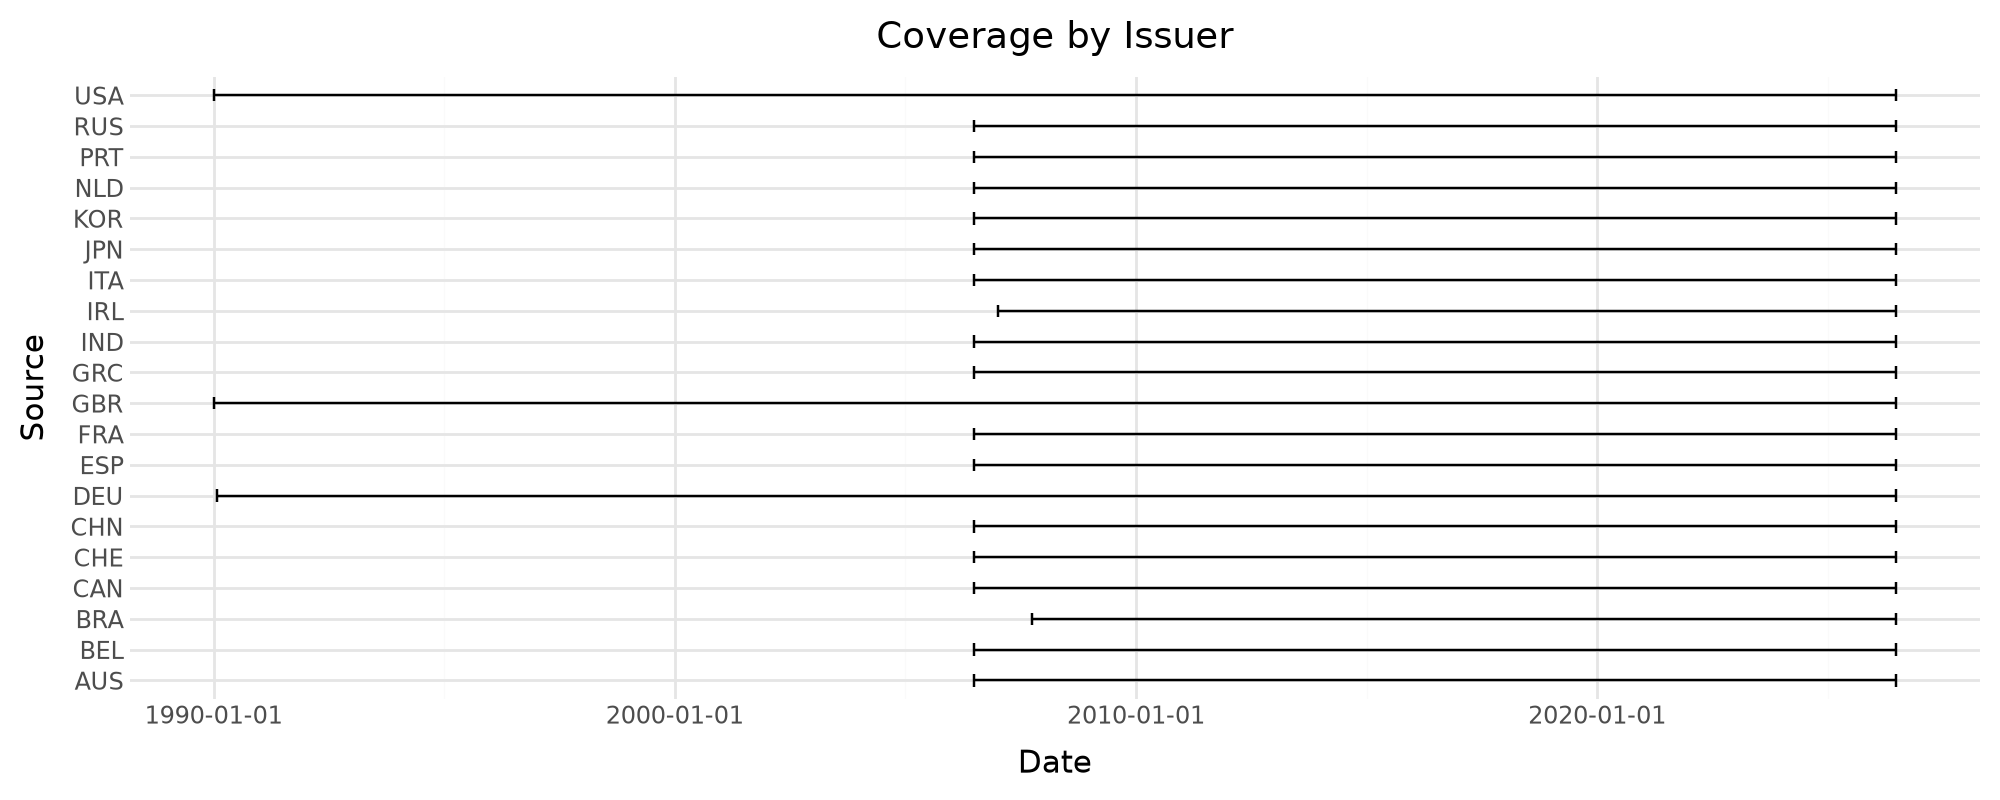

In [8]:
(
    ggplot(coverage, aes(x="min_date", y="source"))
    + geom_errorbarh(
        aes(xmin="min_date", xmax="max_date"),
        height=0.4
    )
    + labs(
        title="Coverage by Issuer",
        x="Date",
        y="Source"
    )
    + theme_minimal() + theme(figure_size=(10,4))
)

## Chapter B: Single-Layer Network Construction

Build intra-layer networks for each term independently, using rolling windows.

### Clean panel and unique keys


In [9]:
# Prepare data: remove nulls, sort
df_clean = df_raw.drop_nulls(subset=['date', 'source', 'term', 'rate']).sort(['date', 'source', 'term'])

print(f"After removing nulls: {df_clean.height:,} rows")

# Extract unique dates and terms for rolling window setup
dates_unique = sorted(df_clean.select('date').unique()['date'].to_list())
terms_unique = sorted(df_clean.select('term').unique()['term'].to_list())
sources_unique = sorted(df_clean.select('source').unique()['source'].to_list())

print(f"\nUnique dates: {len(dates_unique)}")
print(f"Unique terms: {len(terms_unique)}")
print(f"Unique sources: {len(sources_unique)}")

print(f"\nDate range: {dates_unique[0]} to {dates_unique[-1]}")

After removing nulls: 2,957,831 rows

Unique dates: 9775
Unique terms: 27
Unique sources: 20

Date range: 1990-01-02 to 2026-06-24


### Intra-layer network constructor


In [10]:
# Function to build a single-layer network for a specific term over a date window
def build_term_network(
    df: pl.DataFrame,
    term: str,
    date_start,
    date_end,
    measure: str = 'spearman_correlation',
    independent_threshold: float = 0.33
) -> nx.Graph:
    """
    Build a single-layer network for a specific term in a date window.
    Nodes are sources (issuers), edges are correlations of rates over time.
    """
    # Filter by term and date range
    df_term = df.filter(
        (pl.col('term') == term) &
        (pl.col('date') >= date_start) &
        (pl.col('date') <= date_end)
    )
    
    if df_term.height < 3:
        return nx.Graph()  # Empty graph if insufficient data
    
    # Pivot to wide: rows=dates, cols=sources
    df_wide = pivot_to_wide(
        df_term,
        date_column='date',
        name_column='source',
        value_column='rate'
    )
    
    nodes = [c for c in df_wide.columns if c != 'date']
    if len(nodes) < 2:
        return nx.Graph()  # Need at least 2 nodes
    
    # Compute correlation measure
    measure_df = compute_measure(
        measure,
        df_wide.select(nodes),
        nodes,
        progress=None
    )
    
    # Build network
    G = build_corr_nx(measure_df, independent_threshold=independent_threshold)
    
    return G

print("Function defined: build_term_network")

Function defined: build_term_network


### Rolling-window schedule


In [11]:
# Test on a single term with a rolling window
window_size = 125  # 125 trading days
step_size = 21    # Step by 21 days

# Use first term for testing
test_term = terms_unique[0]
print(f"Testing with term: {test_term}")

# Create rolling windows
windows = []
for i in range(0, len(dates_unique) - window_size + 1, step_size):
    date_start = dates_unique[i]
    date_end = dates_unique[i + window_size - 1]
    windows.append((date_start, date_end))

print(f"\nNumber of windows: {len(windows)}")
print(f"First window: {windows[0][0]} to {windows[0][1]}")
print(f"Last window: {windows[-1][0]} to {windows[-1][1]}")

Testing with term: Y000p5

Number of windows: 460
First window: 1990-01-02 to 1990-06-26
Last window: 2025-12-23 to 2026-06-09


### Build networks for every term and window


In [12]:
# Compute intra-layer networks for each term and window
layer_networks = {}  # {term: [G0, G1, ..., Gt]}
layer_metadata = {}  # {term: [(date_start, date_end, |V|, |E|), ...]}

for term in tqdm(terms_unique, desc='Terms'):
    networks = []
    metadata = []
    
    for date_start, date_end in tqdm(windows, desc=f'  {term}', leave=False):
        G = build_term_network(
            df_clean,
            term,
            date_start,
            date_end,
            measure='spearman_correlation',
            independent_threshold=0.33
        )
        networks.append(G)
        metadata.append({
            'term': term,
            'date_start': date_start,
            'date_end': date_end,
            'n_nodes': G.number_of_nodes(),
            'n_edges': G.number_of_edges()
        })
    
    layer_networks[term] = networks
    layer_metadata[term] = metadata

print(f"\nComputed intra-layer networks for {len(layer_networks)} terms")

Terms: 100%|██████████| 27/27 [11:38<00:00, 25.89s/it]


Computed intra-layer networks for 27 terms


### Per-term size and density summary


In [2]:
# Summarize layer statistics
print("Layer Statistics (per term):")
print("Term\t\tAvg Nodes\tAvg Edges\tDensity Range")
for term in terms_unique:
    if term in layer_metadata:
        metadata = layer_metadata[term]
        n_nodes_avg = np.mean([m['n_nodes'] for m in metadata])
        n_edges_avg = np.mean([m['n_edges'] for m in metadata])
        densities = []
        for m in metadata:
            if m['n_nodes'] > 1:
                d = m['n_edges'] / (m['n_nodes'] * (m['n_nodes'] - 1) / 2)
                densities.append(d)
        dens_range = f"[{np.min(densities):.3f}, {np.max(densities):.3f}]"
        print(f"{term}\t\t{n_nodes_avg:.1f}\t\t{n_edges_avg:.1f}\t\t{dens_range}")

Layer Statistics (per term):
Term		Avg Nodes	Avg Edges	Density Range


NameError: name 'terms_unique' is not defined

## Chapter C: Multi-Layer Network Structure

Create inter-layer edges connecting the same source across different terms, forming a yield curve network.

### Multiplex constructor (intra- + inter-layer)


In [14]:
# Create a multi-layer network structure (multiplex graph)
# Node ID format: (source, term)
# Intra-layer edges: source correlations within a term
# Inter-layer edges: same source across terms (with weight 1.0, fully connected)

def build_multilayer_network(
    layer_graphs: dict,  # {term: G_t} where G_t is a NetworkX graph
    terms_list: list,
    inter_layer_weight: float = 1.0
) -> nx.Graph:
    """
    Build a multi-layer network from single-layer graphs.
    Nodes: (source, term) tuples
    Edges: intra-layer (correlation) + inter-layer (yield curve curve connectivity)
    """
    M = nx.Graph()
    
    # Add intra-layer edges (from each layer's network)
    for term in terms_list:
        if term not in layer_graphs:
            continue
        G_term = layer_graphs[term]
        for u, v, data in G_term.edges(data=True):
            # Node IDs: (source, term)
            node_u = (u, term)
            node_v = (v, term)
            weight = 1.0 - data.get('weight', 0.5)  # Convert distance to similarity
            M.add_edge(node_u, node_v, weight=weight, layer='intra', term=term)
    
    # Add inter-layer edges (same source across terms)
    # Collect all sources
    sources = set()
    for term in terms_list:
        if term in layer_graphs:
            sources.update(layer_graphs[term].nodes())
    
    # Connect each source across consecutive terms
    for source in sources:
        for i in range(len(terms_list) - 1):
            term1, term2 = terms_list[i], terms_list[i + 1]
            node1 = (source, term1)
            node2 = (source, term2)
            # Add inter-layer edge
            M.add_edge(node1, node2, weight=inter_layer_weight, layer='inter', source=source)
    
    return M

print("Function defined: build_multilayer_network")

Function defined: build_multilayer_network


### Assemble multiplex graphs for each window


In [15]:
# Build multi-layer networks for the first time window
multilayer_networks = []
window_indices = []

for t_idx, (date_start, date_end) in enumerate(tqdm(windows, desc='Building multi-layer networks')):
    # Collect single-layer graphs for this time window
    layer_graphs_t = {}
    for term in terms_unique:
        if t_idx < len(layer_networks[term]):
            layer_graphs_t[term] = layer_networks[term][t_idx]
    
    # Build multi-layer network
    M_t = build_multilayer_network(
        layer_graphs_t,
        terms_unique,
        inter_layer_weight=1.0
    )
    
    multilayer_networks.append(M_t)
    window_indices.append((date_start, date_end))

print(f"\nBuilt {len(multilayer_networks)} multi-layer networks")

Building multi-layer networks: 100%|██████████| 460/460 [00:02<00:00, 167.01it/s]


Built 460 multi-layer networks


### Snapshot statistics (first windows)


In [16]:
# Analyze multi-layer network structure
print("Multi-Layer Network Statistics\n")
print("Window Index\tDate Start\tDate End\t\tNodes\tEdges\tLayers")
print("-" * 80)
for t_idx, (M, (date_start, date_end)) in enumerate(zip(multilayer_networks, window_indices)):
    n_nodes = M.number_of_nodes()
    n_edges = M.number_of_edges()
    
    # Count layers (unique terms present)
    terms_present = set()
    for node in M.nodes():
        if isinstance(node, tuple):
            terms_present.add(node[1])
    n_layers = len(terms_present)
    
    print(f"{t_idx}\t\t{date_start}\t{date_end}\t{n_nodes}\t{n_edges}\t{n_layers}")
    
    if t_idx > 5:
        print("...")
        break

Multi-Layer Network Statistics

Window Index	Date Start	Date End		Nodes	Edges	Layers
--------------------------------------------------------------------------------
0		1990-01-02	1990-06-26	81	112	27
1		1990-01-31	1990-07-24	81	112	27
2		1990-03-01	1990-08-22	81	106	27
3		1990-03-30	1990-09-20	81	144	27
4		1990-04-30	1990-10-18	81	144	27
5		1990-05-30	1990-11-16	81	128	27
6		1990-06-28	1990-12-17	81	129	27
...


## Chapter D: Multi-Layer Network Metrics

Compute centrality and community metrics accounting for multi-layer structure.

### Metric definitions


In [17]:
# Compute per-layer and multi-layer centrality metrics
def compute_multilayer_metrics(M: nx.Graph, terms_list: list) -> dict:
    """
    Compute centrality metrics for multi-layer network.
    Returns: per-layer and aggregate metrics.
    """
    metrics = {
        'total_nodes': M.number_of_nodes(),
        'total_edges': M.number_of_edges(),
        'density': nx.density(M),
        'n_components': nx.number_connected_components(M),
        'per_layer': {}
    }
    
    # Per-layer metrics
    for term in terms_list:
        # Extract subgraph for this term
        nodes_in_layer = [n for n in M.nodes() if isinstance(n, tuple) and n[1] == term]
        if len(nodes_in_layer) > 0:
            G_layer = M.subgraph(nodes_in_layer)
            metrics['per_layer'][term] = {
                'n_nodes': len(nodes_in_layer),
                'n_edges': G_layer.number_of_edges(),
                'density': nx.density(G_layer) if len(nodes_in_layer) > 1 else 0,
                'n_components': nx.number_connected_components(G_layer)
            }
    
    return metrics

print("Function defined: compute_multilayer_metrics")

Function defined: compute_multilayer_metrics


### Compute metrics across windows


In [18]:
# Compute metrics for all multi-layer networks
multilayer_metrics_list = []

for t_idx, M in enumerate(tqdm(multilayer_networks, desc='Computing metrics')):
    metrics = compute_multilayer_metrics(M, terms_unique)
    metrics['window_idx'] = t_idx
    metrics['date_start'] = window_indices[t_idx][0]
    metrics['date_end'] = window_indices[t_idx][1]
    multilayer_metrics_list.append(metrics)

print(f"Computed metrics for {len(multilayer_metrics_list)} windows")

# Convert to DataFrame for analysis
metrics_data = []
for m in multilayer_metrics_list:
    metrics_data.append({
        'window_idx': m['window_idx'],
        'date_start': m['date_start'],
        'date_end': m['date_end'],
        'total_nodes': m['total_nodes'],
        'total_edges': m['total_edges'],
        'density': m['density'],
        'n_components': m['n_components']
    })

metrics_df = pl.DataFrame(metrics_data)
print("\nMulti-layer network metrics:")
print(metrics_df.head(10))

Computing metrics: 100%|██████████| 460/460 [00:05<00:00, 85.94it/s] 

Computed metrics for 460 windows

Multi-layer network metrics:
shape: (10, 7)
┌────────────┬────────────┬────────────┬─────────────┬─────────────┬──────────┬──────────────┐
│ window_idx ┆ date_start ┆ date_end   ┆ total_nodes ┆ total_edges ┆ density  ┆ n_components │
│ ---        ┆ ---        ┆ ---        ┆ ---         ┆ ---         ┆ ---      ┆ ---          │
│ i64        ┆ str        ┆ str        ┆ i64         ┆ i64         ┆ f64      ┆ i64          │
╞════════════╪════════════╪════════════╪═════════════╪═════════════╪══════════╪══════════════╡
│ 0          ┆ 1990-01-02 ┆ 1990-06-26 ┆ 81          ┆ 112         ┆ 0.034568 ┆ 1            │
│ 1          ┆ 1990-01-31 ┆ 1990-07-24 ┆ 81          ┆ 112         ┆ 0.034568 ┆ 1            │
│ 2          ┆ 1990-03-01 ┆ 1990-08-22 ┆ 81          ┆ 106         ┆ 0.032716 ┆ 1            │
│ 3          ┆ 1990-03-30 ┆ 1990-09-20 ┆ 81          ┆ 144         ┆ 0.044444 ┆ 1            │
│ 4          ┆ 1990-04-30 ┆ 1990-10-18 ┆ 81          ┆ 144         

### Inspect the metrics table


In [19]:
metrics_df.sample(5).sort(['date_start'])
# metrics_df.filter(pl.col("n_components")>1).sample(10).sort(['date_start'])

window_idx,date_start,date_end,total_nodes,total_edges,density,n_components
i64,str,str,i64,i64,f64,i64
39,"""1993-02-23""","""1993-08-13""",81,118,0.03642,1
166,"""2003-06-04""","""2003-11-25""",81,159,0.049074,1
238,"""2009-02-17""","""2009-08-07""",540,2646,0.018182,1
364,"""2018-09-14""","""2019-02-27""",540,4800,0.032983,1
372,"""2019-04-29""","""2019-10-15""",540,5358,0.036817,1


## Chapter E: Temporal Analysis of Multi-Layer Evolution

Analyze how the multi-layer network structure changes over time.

### Aggregate evolution (plotnine)


In [23]:
metrics_df.columns

['window_idx',
 'date_start',
 'date_end',
 'total_nodes',
 'total_edges',
 'density',
 'n_components']

In [ ]:
# Visualize multi-layer network evolution (plotnine)
from plotnine import (
    ggplot,
    aes,
    geom_line,
    facet_wrap,
    labs,
    theme,
    theme_bw,
    scale_color_manual,
    guides,
    element_text,
    element_blank,
)

METRIC_SPECS = {
    "total_nodes": ("Network Size Growth", "#0284c7"),
    "total_edges": ("Edge Count Evolution", "#7c3aed"),
    "density": ("Connectivity Density", "#059669"),
    "n_components": ("Network Fragmentation", "#dc2626"),
}

# x_axis_name = "window_idx"
x_axis_name = "date_end"

plot_df = (
    metrics_df.select([x_axis_name, *METRIC_SPECS.keys()])
    .to_pandas()
    .melt(id_vars=x_axis_name, var_name="metric", value_name="value")
)
plot_df["facet_title"] = plot_df["metric"].map(lambda m: METRIC_SPECS[m][0])
color_map = {m: spec[1] for m, spec in METRIC_SPECS.items()}


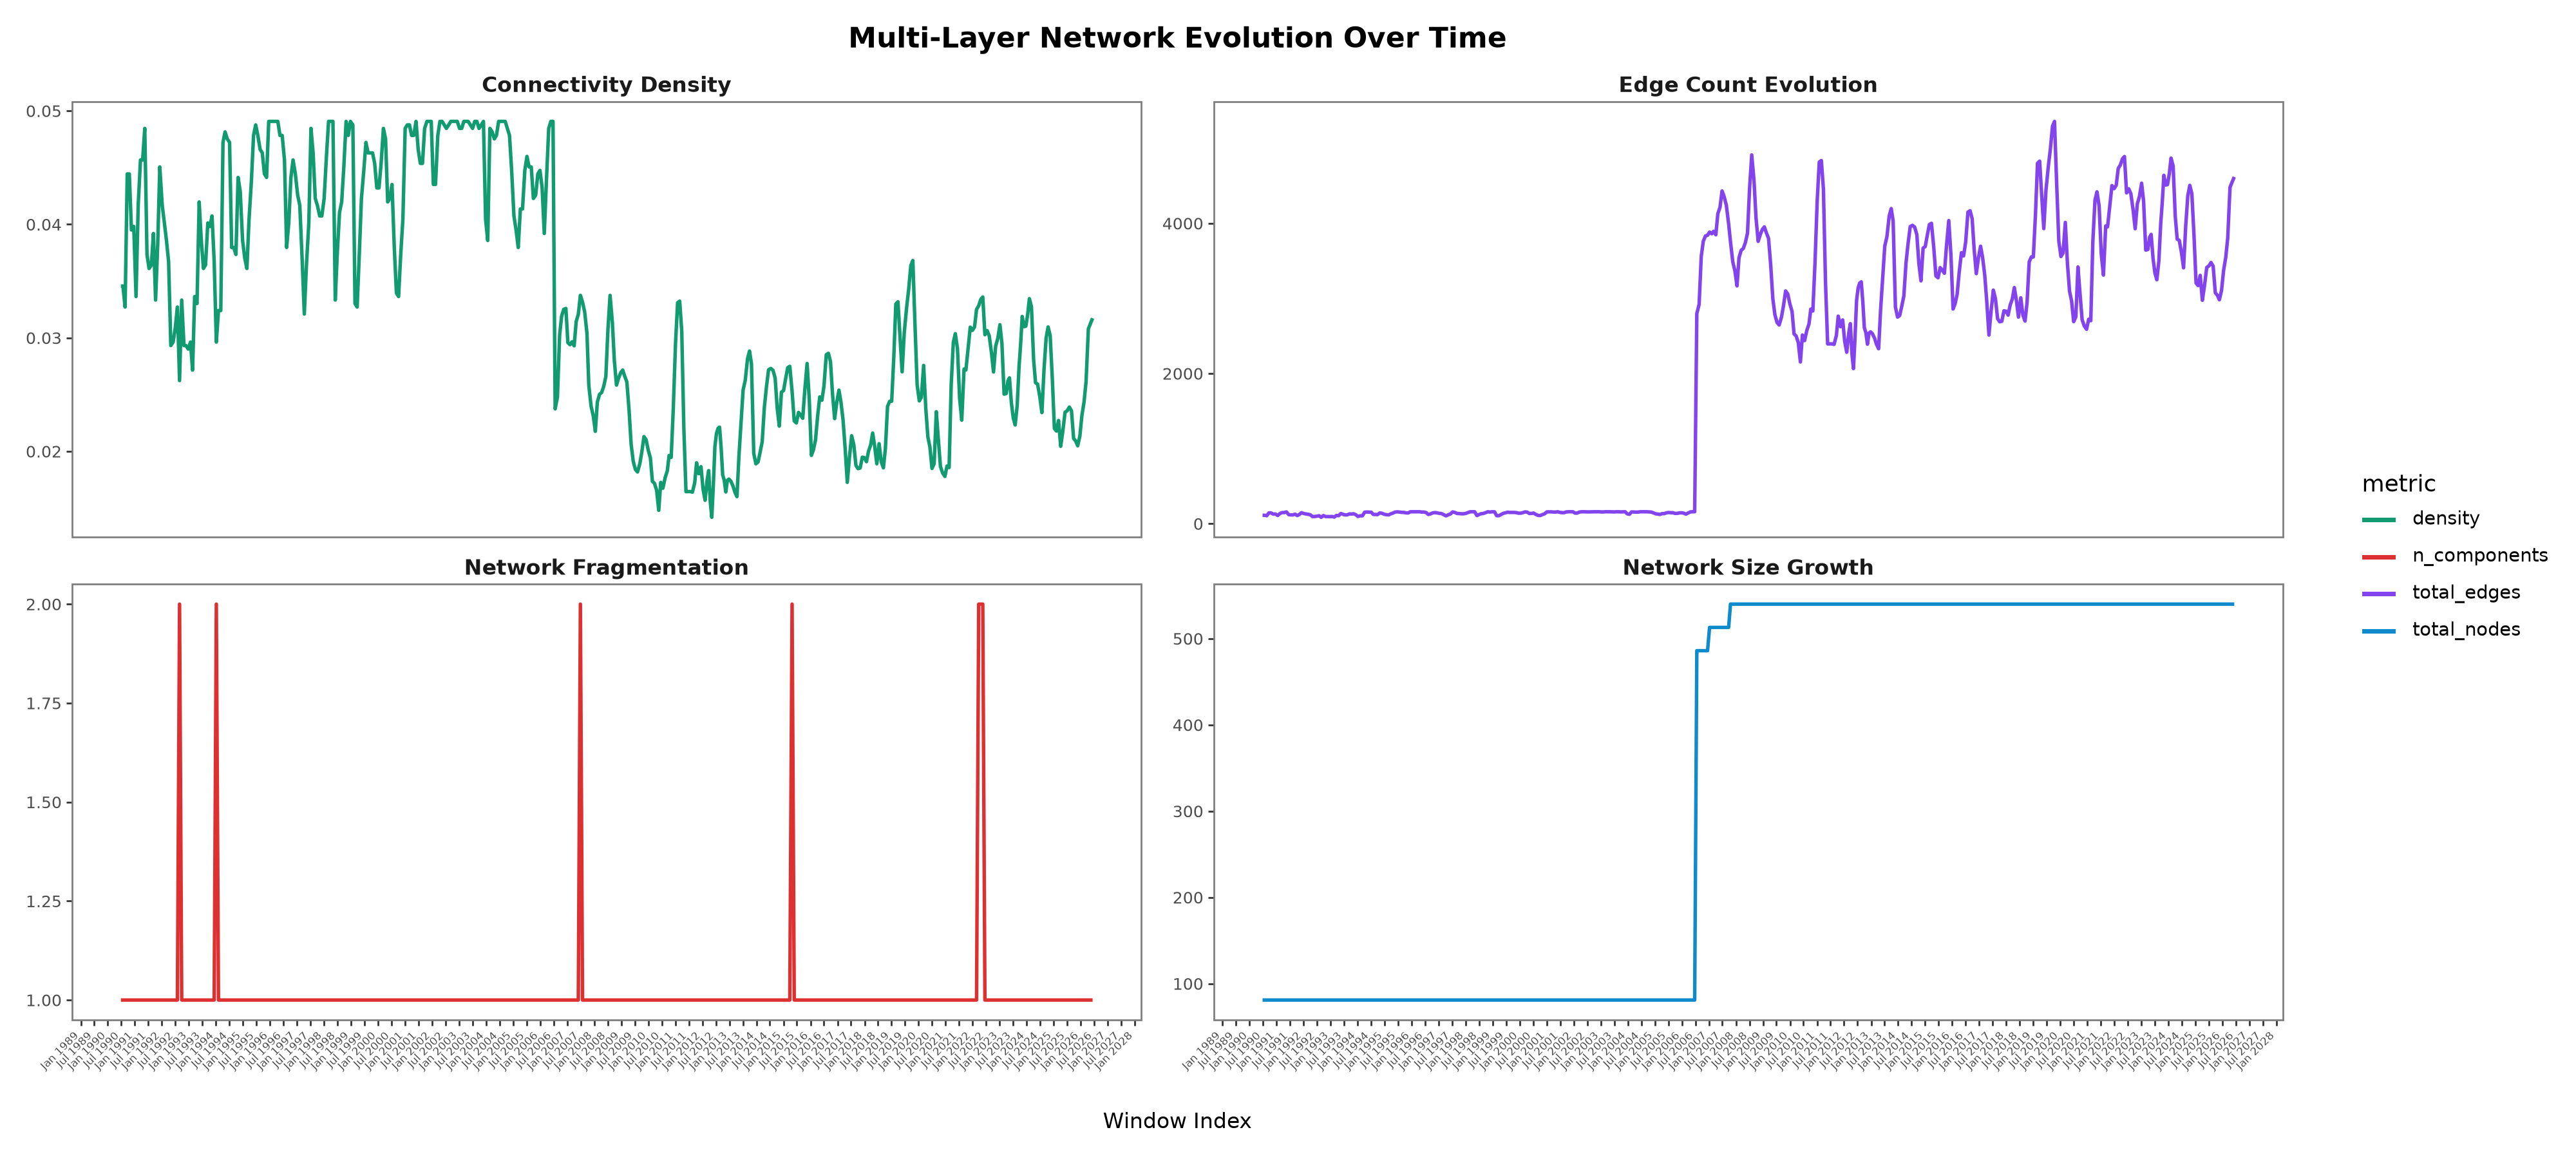

In [32]:
evolution_plot = (
    ggplot(plot_df, aes(x_axis_name, "value", color="metric", group="metric"))
    + geom_line(size=1.1, alpha=0.95)
    + facet_wrap("~ facet_title", ncol=2, scales="free_y")
    + scale_color_manual(values=color_map)
    + scale_x_datetime(
        date_breaks="6 month",       # fewer ticks
        date_labels="%b %Y"           # e.g. Jan 2026
    )
    + guides(color=None)
    + labs(
        title="Multi-Layer Network Evolution Over Time",
        x="Window Index",
        y="",
    )
    + theme_bw(base_size=13)
    + theme(
        figure_size=(20, 9),
        plot_title=element_text(size=16, weight="bold", ha="center"),
        strip_text=element_text(size=12, weight="bold"),
        strip_background=element_blank(),

        # Smaller, angled x-axis labels
        axis_text_x=element_text(
            size=6,
            angle=45,
            ha="right"
        ),

        axis_text_y=element_text(size=9),
        axis_title_x=element_text(size=12, margin={"t": 10}),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
    )
)
evolution_plot

In [33]:
evolution_plot.save(
    "multilayer_evolution.png",
    dpi=150,
    width=14,
    height=8,
    verbose=False,
)

### Per-layer statistics over time


In [34]:
# Per-layer statistics over time
print("Per-Layer Statistics Over Time\n")

per_layer_data = []
for m in multilayer_metrics_list:
    for term, layer_metrics in m.get('per_layer', {}).items():
        per_layer_data.append({
            'window_idx': m['window_idx'],
            'date_end': m['date_end'],
            'term': term,
            'n_nodes': layer_metrics['n_nodes'],
            'n_edges': layer_metrics['n_edges'],
            'density': layer_metrics['density'],
            'n_components': layer_metrics['n_components']
        })

per_layer_df = pl.DataFrame(per_layer_data)

print("Sample per-layer metrics (first 20 rows):")
print(per_layer_df.head(20))

print("\nAverage per-layer metrics:")
per_layer_summary = per_layer_df.group_by('term').agg([
    pl.col('n_nodes').mean().round(1).alias('avg_nodes'),
    pl.col('n_edges').mean().round(1).alias('avg_edges'),
    pl.col('density').mean().round(3).alias('avg_density'),
]).sort('term')
print(per_layer_summary)

Per-Layer Statistics Over Time

Sample per-layer metrics (first 20 rows):
shape: (20, 7)
┌────────────┬────────────┬────────┬─────────┬─────────┬──────────┬──────────────┐
│ window_idx ┆ date_end   ┆ term   ┆ n_nodes ┆ n_edges ┆ density  ┆ n_components │
│ ---        ┆ ---        ┆ ---    ┆ ---     ┆ ---     ┆ ---      ┆ ---          │
│ i64        ┆ str        ┆ str    ┆ i64     ┆ i64     ┆ f64      ┆ i64          │
╞════════════╪════════════╪════════╪═════════╪═════════╪══════════╪══════════════╡
│ 0          ┆ 1990-06-26 ┆ Y000p5 ┆ 3       ┆ 1       ┆ 0.333333 ┆ 2            │
│ 0          ┆ 1990-06-26 ┆ Y001p0 ┆ 3       ┆ 2       ┆ 0.666667 ┆ 1            │
│ 0          ┆ 1990-06-26 ┆ Y001p5 ┆ 3       ┆ 2       ┆ 0.666667 ┆ 1            │
│ 0          ┆ 1990-06-26 ┆ Y002p0 ┆ 3       ┆ 2       ┆ 0.666667 ┆ 1            │
│ 0          ┆ 1990-06-26 ┆ Y002p5 ┆ 3       ┆ 2       ┆ 0.666667 ┆ 1            │
│ …          ┆ …          ┆ …      ┆ …       ┆ …       ┆ …        ┆ …            

### Interactive network visualization (pyvis)

Column **hue** = issuer (vertical columns share a color). Node **size and brightness** increase from short to long maturities (`Y000p5` → `Y030p0`).

Intra-layer edges (same term, any issuer pair) use **bright blue → white → yellow** and **thickness** for connection strength. They are drawn as **arcs**, so AUS–USA at `Y000p5` appears as a curve along that row — not only between alphabetically adjacent columns. If there is no arc, that pair was below the correlation threshold.

Faint vertical rails are inter-layer links (same issuer, adjacent terms). Hover an edge for the numeric strength; scroll to zoom.


In [35]:
# window_indices

In [36]:
import base64

from IPython.display import HTML, display

from ycn.analysis.pyvis_plot import multilayer_graph_to_html

multilayer_index = -10
w0_start, w0_end = window_indices[multilayer_index]
html = multilayer_graph_to_html(
    multilayer_networks[multilayer_index],
    title=f"Multi-Layer Network (window {multilayer_index}: {w0_start} → {w0_end})",
    height="900px",
)
encoded = base64.b64encode(html.encode("utf-8")).decode("ascii")
display(
    HTML(
        "<p style='color:#cbd5e1;font-family:Segoe UI,sans-serif;margin:0 0 8px 0'>"
        "Columns = issuers (same hue down a column). Rows = terms, short→long (larger/brighter nodes). Intra-layer arcs: blue=weak, yellow=strong. Non-adjacent pairs (e.g. AUS–USA) are the long curves in a row. Hover an edge for strength. Bottom-right: zoom / fit. "
        "Scroll to zoom, drag to pan, hover for node/edge details. "
        "Bottom-right buttons: zoom / fit."
        "</p>"
        f'<iframe src="data:text/html;base64,{encoded}" '
        'width="100%" height="900px" frameborder="0" '
        'style="border:1px solid #334155; background:#0f172a;"></iframe>'
    )
)


In [37]:
### Interactive network visualization (MultiLayerNetViz)

In [38]:
import io
import sys
from pathlib import Path

from IPython.display import Image, display
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, to_hex

from multi_layer_NetViz_fcts import Layer, LayeredNetworkGraph

plt.rcParams["text.usetex"] = False  # the module enables usetex on import; turn it off on Windows

# plot_surface otherwise maps each plane through the default colormap by z
_orig_draw_plane = getattr(LayeredNetworkGraph._draw_plane, "_orig", LayeredNetworkGraph._draw_plane)

def _draw_plane_lightgrey(self, layer, *args, **kwargs):
    kwargs.setdefault("color", "lightgrey")
    kwargs.setdefault("shade", False)
    kwargs.setdefault("linewidth", 0)
    kwargs.setdefault("antialiased", True)
    return _orig_draw_plane(self, layer, *args, **kwargs)

_draw_plane_lightgrey._orig = _orig_draw_plane
LayeredNetworkGraph._draw_plane = _draw_plane_lightgrey


def _display_fig(fig: Figure) -> None:
    """Emit a PNG so Cursor notebooks show the figure, not just its repr."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight", facecolor="white")
    buf.seek(0)
    display(Image(data=buf.getvalue()))


def _shared_circular_layout(issuers: list[str]):
    """Same (x, y) for a given issuer on every layer."""
    n = max(len(issuers), 1)
    angles = np.linspace(0.0, 2.0 * np.pi, n, endpoint=False)
    xy = {
        s: (float(np.cos(a)), float(np.sin(a)))
        for s, a in zip(issuers, angles)
    }

    def layout(G, *args, **kwargs):
        return {node: xy[node] for node in G.nodes()}

    return layout


def _intra_graph(G: nx.Graph, term: str) -> nx.Graph:
    H = nx.Graph()
    for u, v, data in G.edges(data=True):
        if data.get("layer") == "inter":
            continue
        if not (isinstance(u, tuple) and isinstance(v, tuple)):
            continue
        if u[1] != term or v[1] != term:
            continue
        H.add_edge(u[0], v[0], weight=float(data.get("weight", 0.5)))
    for n in G.nodes():
        if isinstance(n, tuple) and n[1] == term:
            H.add_node(n[0])
    return H


def _edge_weights(H: nx.Graph) -> list[float]:
    return [float(d.get("weight", 0.5)) for _, _, d in H.edges(data=True)]


def _edge_colors(weights: list[float], vmin: float, vmax: float) -> list[str]:
    if not weights:
        return []
    span = vmax - vmin if vmax > vmin else 1.0
    return [to_hex(plt.cm.plasma((w - vmin) / span)) for w in weights]


def plot_multilayer_netviz(
    G: nx.Graph,
    terms: list[str],
    title: str = "Yield-curve multiplex",
    layer_gap: float = 2.8,
):
    issuers = sorted({n[0] for n in G.nodes() if isinstance(n, tuple)})
    layout = _shared_circular_layout(issuers)
    cmap = plt.cm.tab20
    graphs = [_intra_graph(G, term) for term in terms]

    all_w = [w for H in graphs for w in _edge_weights(H)]
    wmin, wmax = (min(all_w), max(all_w)) if all_w else (0.0, 1.0)

    layers = []
    for i, (term, H) in enumerate(zip(terms, graphs)):
        node_color = {
            s: to_hex(cmap(issuers.index(s) % 20)) for s in H.nodes()
        }
        layers.append(
            Layer(
                H,
                z_pos=float(i) * layer_gap,
                label=term,
                layout=layout,
                node_size=90,
                node_color=node_color,          # dict, not a list
                text_color={s: "black" for s in H.nodes()},
                edge_color=_edge_colors(_edge_weights(H), wmin, wmax) or "dimgrey",
                node_label={s: s for s in H.nodes()},
                node_alpha=0.95,
                edge_alpha=0.55,
                plane_alpha=0.25,
            )
        )

    interlayer = []
    for i in range(len(terms) - 1):
        common = set(layers[i].graph.nodes()) & set(layers[i + 1].graph.nodes())
        for s in common:
            interlayer.append((s, s, i, i + 1))  # (u, v, layer_index, layer_index)

    # Standalone Figure so the inline backend does not auto-display it again
    fig = Figure(figsize=(11, 9))
    FigureCanvasAgg(fig)
    ax = fig.add_subplot(111, projection="3d")
    viz = LayeredNetworkGraph(layers, interlayer_edges=interlayer, ax=ax)
    viz.draw()
    ax.set_title(title)
    ax.set_axis_off()

    sm = ScalarMappable(cmap=plt.cm.plasma, norm=Normalize(vmin=wmin, vmax=wmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.08, fraction=0.035)
    cbar.set_label("Intra-layer connection strength")

    fig.tight_layout()
    _display_fig(fig)
    return fig, ax


In [39]:
# from pathlib import Path
# import pickle
# out_path = Path("D:/Code/MultiLayerNetViz/resources/data/multilayer_network.pkl")
# payload = {
#     "graph": multilayer_networks[multilayer_index],
#     "index": multilayer_index,
#     "window": window_indices[multilayer_index],
# }
# with out_path.open("wb") as f:
#     pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

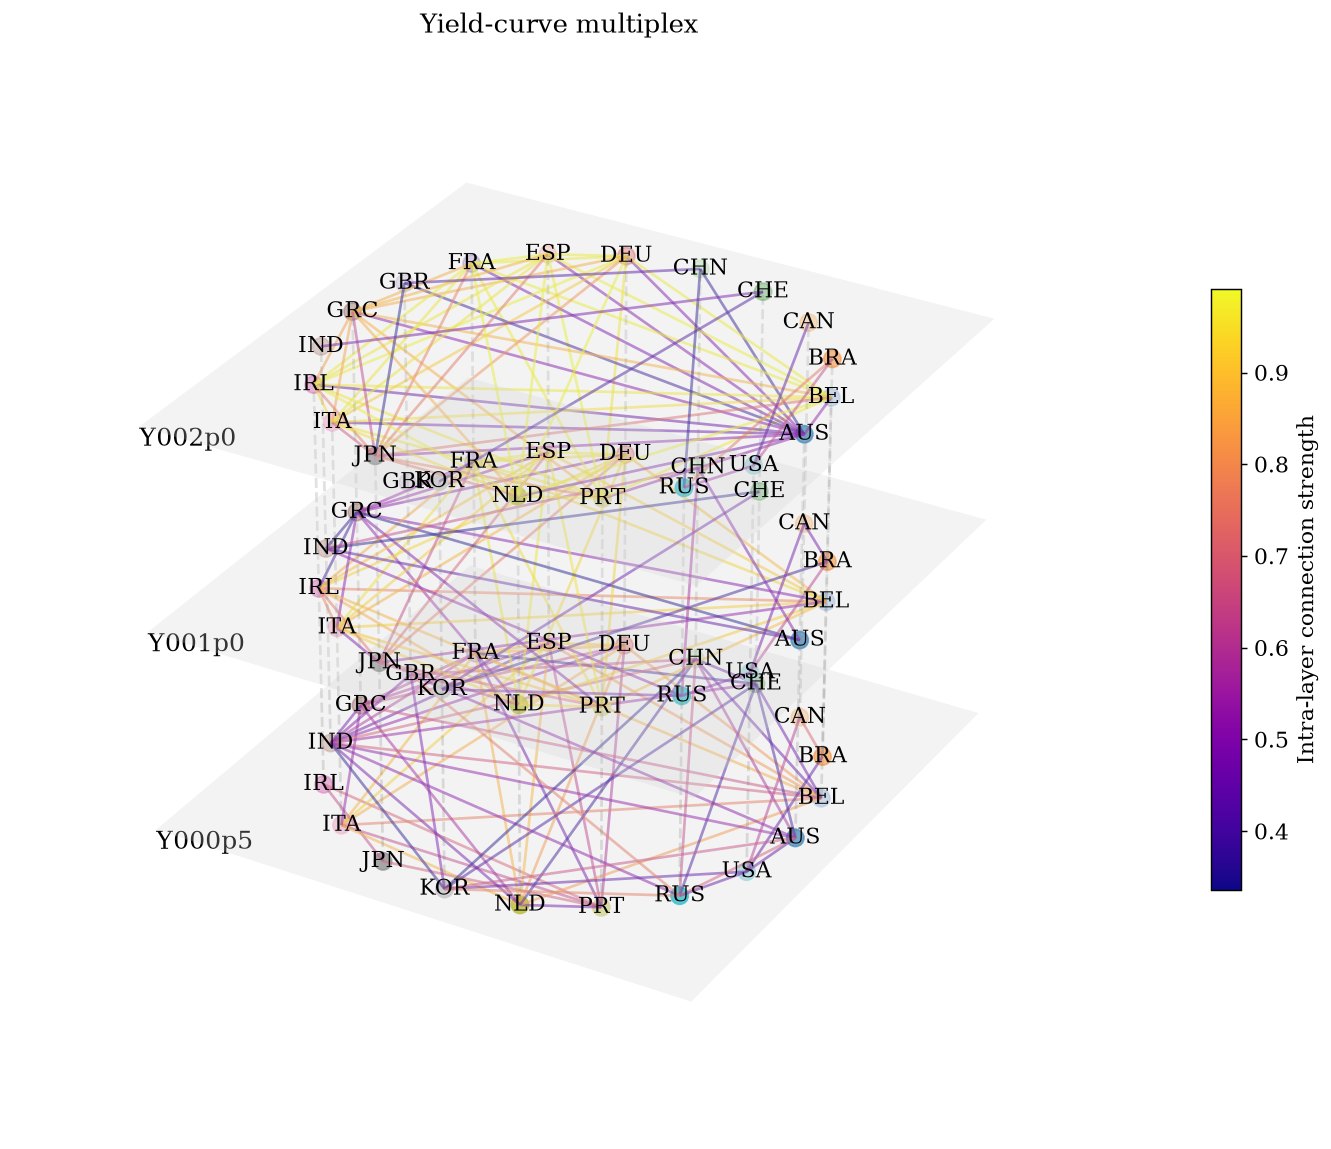

<Figure size 1100x900 with 2 Axes>

In [40]:
terms_keep = ["Y000p5", "Y001p0", "Y002p0"]
G_full = multilayer_networks[multilayer_index]
G_small = G_full.subgraph(
    [n for n in G_full.nodes() if isinstance(n, tuple) and n[1] in terms_keep]
).copy()
fig, ax = plot_multilayer_netviz(G_small, terms_keep)
fig

## Chapter F: Inter-Layer Connectivity Analysis

Analyze how yield curve structure (inter-layer connectivity) evolves over time.

### Count intra- vs inter-layer edges


In [41]:
# Count inter-layer vs intra-layer edges
def count_edge_types(M: nx.Graph) -> dict:
    """
    Count edges by type (intra-layer vs inter-layer).
    """
    intra_edges = 0
    inter_edges = 0
    
    for u, v, data in M.edges(data=True):
        edge_layer = data.get('layer', 'unknown')
        if edge_layer == 'intra':
            intra_edges += 1
        elif edge_layer == 'inter':
            inter_edges += 1
    
    return {
        'intra_edges': intra_edges,
        'inter_edges': inter_edges,
        'total_edges': intra_edges + inter_edges
    }

edge_type_data = []
for t_idx, M in enumerate(multilayer_networks):
    counts = count_edge_types(M)
    counts['window_idx'] = t_idx
    counts['date_end'] = window_indices[t_idx][1]
    edge_type_data.append(counts)

edge_type_df = pl.DataFrame(edge_type_data)
edge_type_df = edge_type_df.with_columns([
    (100.0 * pl.col('intra_edges') / pl.col('total_edges')).alias('pct_intra'),
    (100.0 * pl.col('inter_edges') / pl.col('total_edges')).alias('pct_inter')
])

print("Edge Type Distribution Over Time:")
print(edge_type_df.head(15))

Edge Type Distribution Over Time:
shape: (15, 7)
┌─────────────┬─────────────┬─────────────┬────────────┬────────────┬───────────┬───────────┐
│ intra_edges ┆ inter_edges ┆ total_edges ┆ window_idx ┆ date_end   ┆ pct_intra ┆ pct_inter │
│ ---         ┆ ---         ┆ ---         ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│ i64         ┆ i64         ┆ i64         ┆ i64        ┆ str        ┆ f64       ┆ f64       │
╞═════════════╪═════════════╪═════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ 34          ┆ 78          ┆ 112         ┆ 0          ┆ 1990-06-26 ┆ 30.357143 ┆ 69.642857 │
│ 34          ┆ 78          ┆ 112         ┆ 1          ┆ 1990-07-24 ┆ 30.357143 ┆ 69.642857 │
│ 28          ┆ 78          ┆ 106         ┆ 2          ┆ 1990-08-22 ┆ 26.415094 ┆ 73.584906 │
│ 66          ┆ 78          ┆ 144         ┆ 3          ┆ 1990-09-20 ┆ 45.833333 ┆ 54.166667 │
│ 66          ┆ 78          ┆ 144         ┆ 4          ┆ 1990-10-18 ┆ 45.833333 ┆ 54.166667 │
│ …        

### Edge-type composition over time (plotnine)


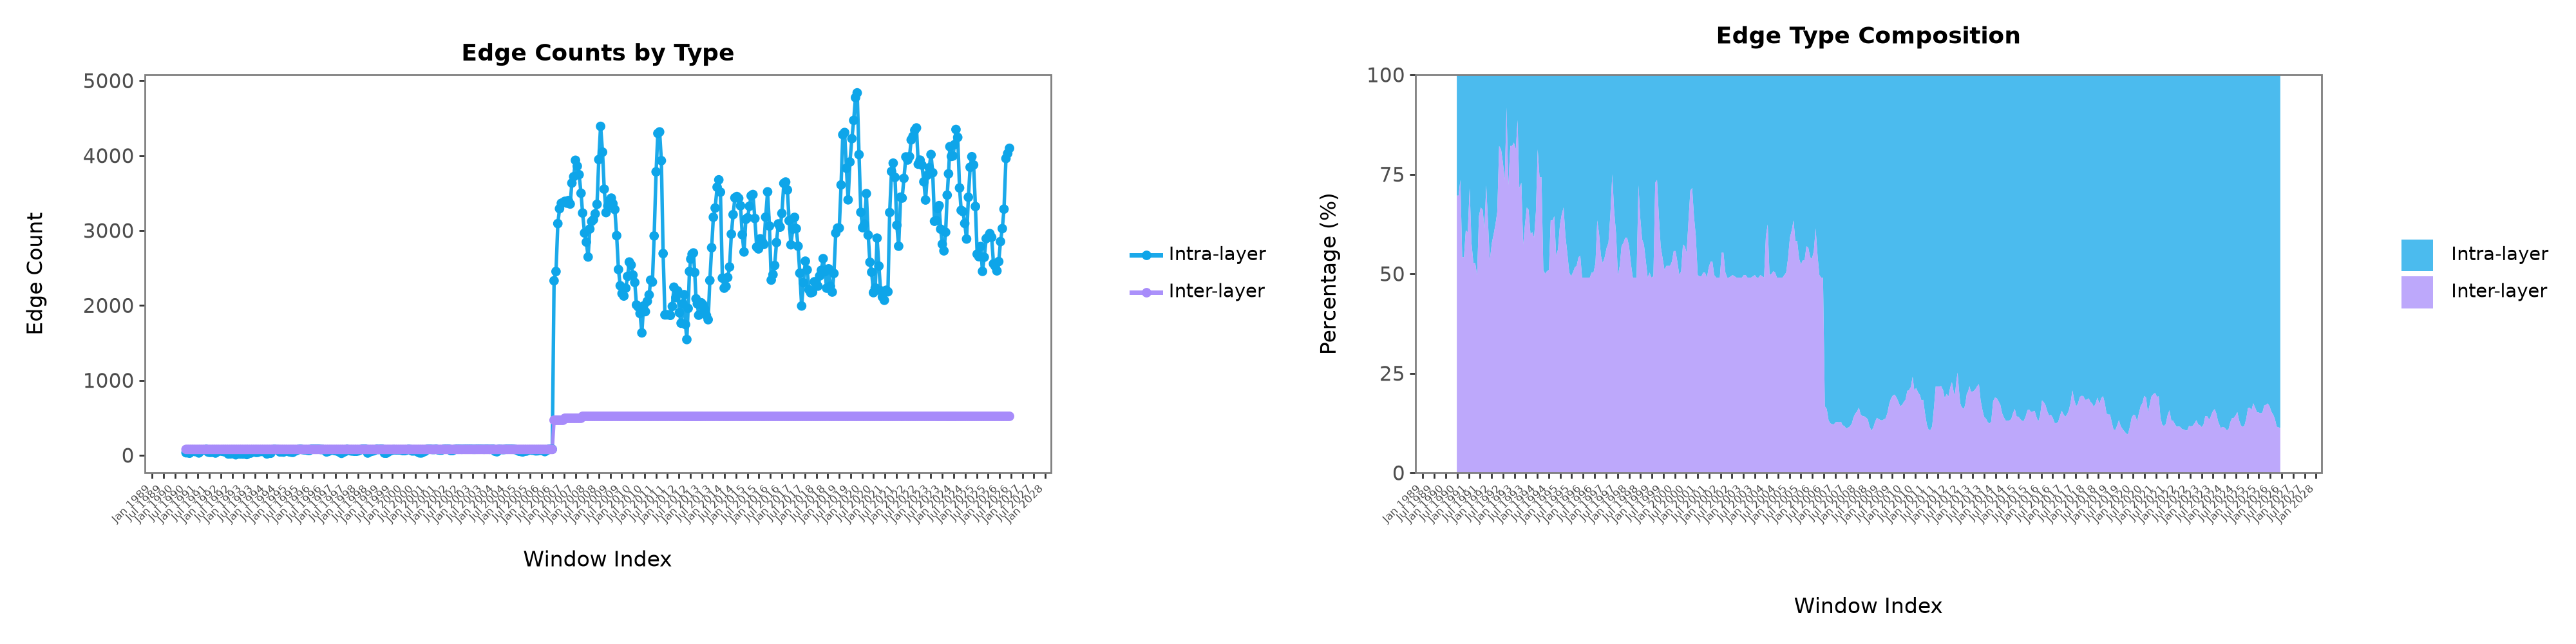

In [54]:
# Visualize edge type evolution (plotnine)
import pandas as pd
from plotnine import (
    ggplot,
    aes,
    geom_line,
    geom_point,
    geom_area,
    labs,
    theme,
    theme_bw,
    scale_color_manual,
    scale_fill_manual,
    scale_y_continuous,
    element_text,
    element_blank,
)

EDGE_COLORS = {
    "Intra-layer": "#0ea5e9",
    "Inter-layer": "#a78bfa",
}
EDGE_ORDER = ["Intra-layer", "Inter-layer"]

# x_axis_name = "window_idx"
x_axis_name = "date_end"

counts_df = (
    edge_type_df.select([x_axis_name, "intra_edges", "inter_edges"])
    .unpivot(
        index=x_axis_name,
        on=["intra_edges", "inter_edges"],
        variable_name="edge_type",
        value_name="count",
    )
    .with_columns(
        pl.col("edge_type").replace_strict(
            {"intra_edges": "Intra-layer", "inter_edges": "Inter-layer"}
        )
    )
    .to_pandas()
)
counts_df["edge_type"] = pd.Categorical(
    counts_df["edge_type"], categories=EDGE_ORDER, ordered=True
)

comp_df = (
    edge_type_df.select([x_axis_name, "pct_intra", "pct_inter"])
    .unpivot(
        index=x_axis_name,
        on=["pct_intra", "pct_inter"],
        variable_name="edge_type",
        value_name="pct",
    )
    .with_columns(
        pl.col("edge_type").replace_strict(
            {"pct_intra": "Intra-layer", "pct_inter": "Inter-layer"}
        )
    )
    .to_pandas()
)
comp_df["edge_type"] = pd.Categorical(
    comp_df["edge_type"], categories=EDGE_ORDER, ordered=True
)

_panel_theme = (
    theme_bw(base_size=13)
    + theme(
        plot_title=element_text(size=13, weight="bold"),
        axis_text=element_text(size=11),
        axis_title=element_text(size=12),
        legend_title=element_blank(),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
    )
)

_xaxis_theme = theme(
    axis_text_x=element_text(
        size=6,
        angle=45,
        ha="right",
    ),
    axis_title_x=element_text(
        size=12,
        margin={"t": 10},
    ),
)

p_counts = (
    ggplot(
        counts_df,
        aes(x_axis_name, "count", color="edge_type", group="edge_type")
    )
    + geom_line(size=1.1, alpha=0.95)
    + geom_point(size=2)
    + scale_color_manual(values=EDGE_COLORS)
    + scale_x_datetime(
        date_breaks="6 months",
        date_labels="%b %Y",
    )
    + labs(
        title="Edge Counts by Type",
        x="Window Index",
        y="Edge Count",
        color="",
    )
    + _panel_theme
    + _xaxis_theme
)

p_comp = (
    ggplot(
        comp_df,
        aes(x_axis_name, "pct", fill="edge_type", group="edge_type")
    )
    + geom_area(position="stack", alpha=0.75)
    + scale_fill_manual(values=EDGE_COLORS)
    + scale_y_continuous(limits=(0, 100), expand=(0, 0))
    + scale_x_datetime(
        date_breaks="6 months",
        date_labels="%b %Y",
    )
    + labs(
        title="Edge Type Composition",
        x="Window Index",
        y="Percentage (%)",
        fill="",
    )
    + _panel_theme
    + _xaxis_theme
)

edge_type_plot = (
    p_counts | p_comp
) + theme(
    figure_size=(20, 5)
)

edge_type_plot


In [55]:
edge_type_plot.save(
    "multilayer_edge_types.png",
    dpi=150,
    width=14,
    height=4.2,
    verbose=False,
)

## Chapter G: Community Detection in Multi-Layer Networks

Detect communities on each multiplex snapshot (intra- + inter-layer edges). A snapshot
is the multi-layer analogue of a single-network **window**: ASE + KMeans with *k*
chosen from that multiplex only — no lookahead across time. The five README
**Community Detection Methods** apply unchanged, with the supra-adjacency in place
of the single-layer adjacency.

### Spectral embedding + KMeans detector (five k-selection methods)

`detect_multilayer_communities` delegates to the same strategies as evolution:

1. **FIXED** — hard *k* (`MAX_COMMUNITIES`) on every multiplex snapshot
2. **SILHOUETTE** — maximize average silhouette in ASE space
3. **MODULARITY** — maximize modularity on the multiplex graph
4. **DAVIES-BOULDIN** — minimize Davies-Bouldin index in latent space
5. **CALINSKI-HARABASZ** — maximize Calinski-Harabasz index in latent space


In [75]:
# Multiplex ASE + KMeans; method selects k (no lookahead across windows).
from ycn.analysis.evolution import CommunityMethod
from ycn.analysis.multilayer_communities import (
    METHOD_LABELS,
    detect_multilayer_communities,
)

MAX_COMMUNITIES = 8
ASE_N_COMPONENTS = 8

def detect_multilayer_communities_dispatch(
    M: nx.Graph,
    method: CommunityMethod | str = CommunityMethod.FIXED,
    *,
    n_components: int = ASE_N_COMPONENTS,
    max_clusters: int = MAX_COMMUNITIES,
) -> dict:
    """Delegate multiplex community detection to a README k-selection method.

    Args:
        M: Multiplex graph (nodes are ``(issuer, term)``).
        method: ``CommunityMethod`` or its string value.
        n_components: ASE latent dimension.
        max_clusters: Exact k for FIXED; search cap for the other methods.
    """
    if isinstance(method, str):
        method = CommunityMethod(method)
    return detect_multilayer_communities(
        M,
        method,
        max_clusters=max_clusters,
        ase_n_components=n_components,
    )


def detect_multilayer_communities_legacy(
    M: nx.Graph, n_components: int = ASE_N_COMPONENTS
) -> dict:
    """Back-compat alias: FIXED k on the multiplex snapshot."""
    return detect_multilayer_communities_dispatch(
        M, CommunityMethod.FIXED, n_components=n_components
    )

print("Dispatchers:", ", ".join(METHOD_LABELS.values()))
print("Example: detect_multilayer_communities_dispatch(M, method='silhouette')")


Dispatchers: FIXED, SILHOUETTE, MODULARITY, DAVIES-BOULDIN, CALINSKI-HARABASZ
Example: detect_multilayer_communities_dispatch(M, method='silhouette')


### Number of multiplex windows


In [76]:
len(multilayer_networks)

460

### Communities on the first windows


In [77]:
# Detect communities for every multiplex window × every k-selection method.
multilayer_communities = []

for method in CommunityMethod:
    label = METHOD_LABELS[method]
    for t_idx, M in enumerate(tqdm(multilayer_networks, desc=label)):
        result = detect_multilayer_communities_dispatch(
            M, method, n_components=ASE_N_COMPONENTS, max_clusters=MAX_COMMUNITIES
        )
        result["window_idx"] = t_idx
        result["date_end"] = window_indices[t_idx][1]
        multilayer_communities.append(result)

print("\nCommunity detection (first window, all methods):")
for result in multilayer_communities:
    if result["window_idx"] != 0:
        continue
    score = result.get("score", float("nan"))
    print(f"  {result['method']}: {result['n_clusters']} communities, score={score:.4g}")


CALINSKI-HARABASZ: 100%|██████████| 460/460 [04:16<00:00,  1.80it/s]


Community detection (first window, all methods):
  FIXED: 8 communities, score=0.4953
  SILHOUETTE: 8 communities, score=0.4953
  MODULARITY: 8 communities, score=0.05246
  DAVIES-BOULDIN: 8 communities, score=0.7655
  CALINSKI-HARABASZ: 8 communities, score=30.44


In [78]:
result.keys()

dict_keys(['communities', 'n_clusters', 'score', 'inertia', 'method', 'window_idx', 'date_end'])

In [79]:
rows = []
for d in multilayer_communities:
    communities = d["communities"]
    for (issuer, term), community in communities.items():
        rows.append(
            {
                "method": d["method"],
                "n_clusters": d["n_clusters"],
                "score": d.get("score", d.get("inertia")),
                "window_idx": d["window_idx"],
                "date_end": d["date_end"],
                "issuer": issuer,
                "term": term,
                "community": community,
            }
        )

df_communities = pl.DataFrame(rows)
if df_communities.height and df_communities["date_end"].dtype == pl.Utf8:
    df_communities = df_communities.with_columns(pl.col("date_end").str.to_date())
df_communities.head()


method,n_clusters,score,window_idx,date_end,issuer,term,community
str,i64,f64,i64,date,str,str,i64
"""FIXED""",8,0.495269,0,1990-06-26,"""DEU""","""Y000p5""",2
"""FIXED""",8,0.495269,0,1990-06-26,"""DEU""","""Y001p0""",2
"""FIXED""",8,0.495269,0,1990-06-26,"""DEU""","""Y001p5""",2
"""FIXED""",8,0.495269,0,1990-06-26,"""DEU""","""Y002p0""",5
"""FIXED""",8,0.495269,0,1990-06-26,"""DEU""","""Y002p5""",4


In [80]:
df_communities.sample(5)

method,n_clusters,score,window_idx,date_end,issuer,term,community
str,i64,f64,i64,date,str,str,i64
"""MODULARITY""",8,0.757596,422,2023-08-25,"""CHE""","""Y025p0""",0
"""MODULARITY""",8,0.720531,383,2020-08-27,"""FRA""","""Y012p0""",0
"""DAVIES-BOULDIN""",8,0.791314,267,2011-11-14,"""IND""","""Y010p0""",2
"""SILHOUETTE""",7,0.42939,437,2024-09-19,"""FRA""","""Y006p0""",1
"""DAVIES-BOULDIN""",8,0.884832,305,2014-07-14,"""ITA""","""Y006p0""",0


### Selected *k* by method over time


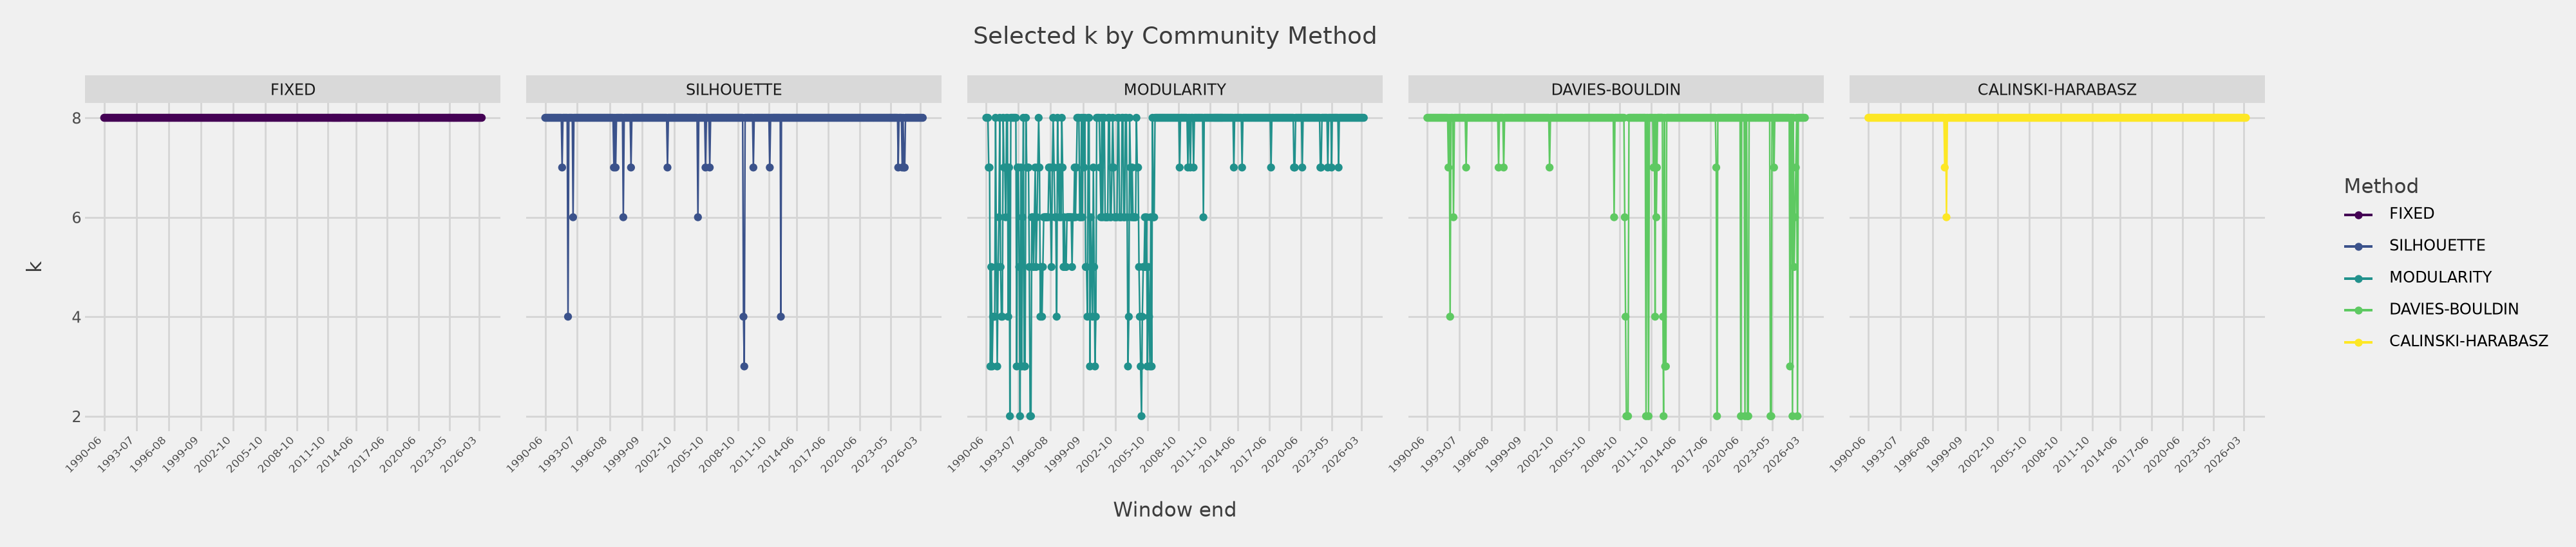

In [100]:
# One row per (method, window); n_clusters is the k chosen for that snapshot.
import pandas as pd
from mizani.breaks import date_breaks
from mizani.formatters import date_format
k_df = (
    df_communities.select(["method", "date_end", "window_idx", "n_clusters", "score"])
    .unique(subset=["method", "window_idx"])
    .sort(["method", "date_end"])
)
k_plot_df = k_df.to_pandas()
k_plot_df["method"] = pd.Categorical(
    k_plot_df["method"], categories=list(METHOD_LABELS.values()), ordered=True
)

dates = np.sort(k_plot_df["date_end"].unique())
step = max(1, len(dates) // 12)
breaks = dates[::step]

(
    ggplot(k_plot_df, aes("date_end", "n_clusters", color="method"))
    + geom_line()
    + geom_point(size=1.5)
    + scale_x_date(
        breaks=breaks,
        labels=date_format("%Y-%m"),
    )
    + labs(
        title="Selected k by Community Method",
        x="Window end",
        y="k",
        color="Method",
    )
    + theme_538()
    + facet_grid(".~method")
    + theme(
        figure_size=(20, 4.25),
        axis_text_x=element_text(size=6, angle=45, ha="right"),
    )
)


### Issuer membership over time (FIXED method)


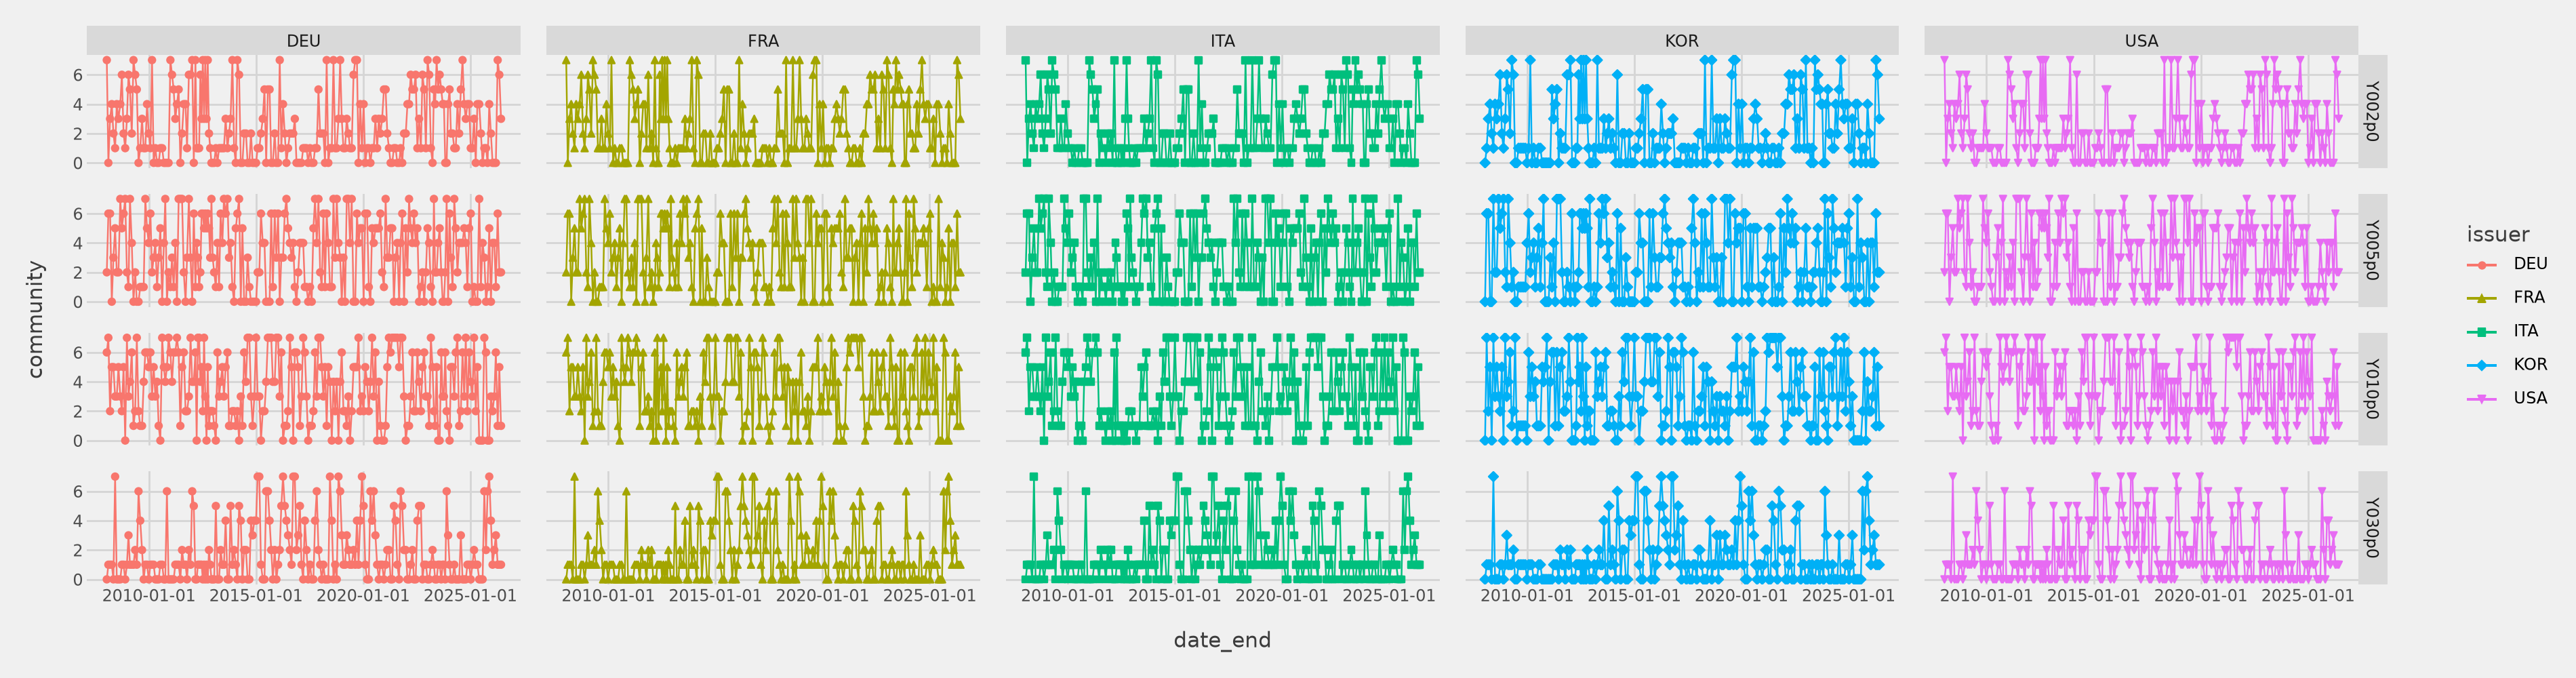

In [82]:
ggplot(
    df_communities.filter(pl.col("method") == "FIXED")
    .filter(pl.col("issuer").is_in(["DEU", "ITA", "USA", "FRA", "GRE", "KOR"]))
    .filter(pl.col("term").is_in(["Y002p0", "Y005p0", "Y010p0", "Y030p0"]))
    .filter(pl.col("date_end") > pl.lit(date(2007, 12, 31))),
    aes("date_end", "community", fill="issuer", shape="issuer", color="issuer"),
) + geom_point() + geom_line(group="term") + facet_grid("term~issuer") + theme_538() + theme(
    figure_size=(19, 5)
)

In [101]:
# Mean selected k and score by method (one value per window, then averaged).
(
    df_communities.select(["method", "window_idx", "n_clusters", "score"])
    .unique(subset=["method", "window_idx"])
    .group_by("method")
    .agg(
        pl.col("n_clusters").mean().alias("mean_k"),
        pl.col("n_clusters").min().alias("min_k"),
        pl.col("n_clusters").max().alias("max_k"),
        pl.col("score").mean().alias("mean_score"),
    )
    .sort("method")
)


method,mean_k,min_k,max_k,mean_score
str,f64,i64,i64,f64
"""CALINSKI-HARABASZ""",7.993478,6,8,130.181055
"""DAVIES-BOULDIN""",7.686957,2,8,0.803684
"""FIXED""",8.0,8,8,0.525365
"""MODULARITY""",7.119565,2,8,0.660675
"""SILHOUETTE""",7.921739,3,8,0.526887


# Part II: Factor Models, Residuals, and Stress

Chapters H–O continue from the panel already loaded in Part I (enhanced notebook reload/coverage cells are omitted as duplicates).


## Chapter H: Yield Curve Factor Extraction (Nelson-Siegel & PCA)

Extract interpretable factors (level, slope, curvature) that drive yield curve dynamics.

### Market-wide Nelson-Siegel factors


In [84]:
# Fit Nelson-Siegel model to average curve across all issuers (market-wide curve)
# This gives us "common factors" shared across market

# Group by date, average across all sources
df_market = df_clean.group_by('date').agg([
    pl.col('rate').mean().alias('rate')
]).sort('date')

# Pivot: dates ├ù terms
df_market_wide = pivot_to_wide(
    df_clean.group_by(['date', 'term']).agg(pl.col('rate').mean().alias('rate')),
    date_column='date',
    name_column='term',
    value_column='rate'
)

term_cols = [c for c in df_market_wide.columns if c != 'date']
print(f"Market-wide yield matrix: {df_market_wide.height} dates ├ù {len(term_cols)} terms")

# Fit Nelson-Siegel for market-wide curve
ns_market = fit_nelson_siegel_batch(
    df_market_wide,
    date_col='date',
    maturities=term_cols,
    decay=1.0  # Fixed lambda for stability
)

print("\nNelson-Siegel factors (market average):")
print(ns_market.head(10))

Market-wide yield matrix: 9775 dates ├ù 27 terms

Nelson-Siegel factors (market average):
shape: (10, 6)
┌────────────┬──────────┬──────────┬───────────┬───────┬──────────┐
│ date       ┆ level    ┆ slope    ┆ curvature ┆ decay ┆ rmse     │
│ ---        ┆ ---      ┆ ---      ┆ ---       ┆ ---   ┆ ---      │
│ str        ┆ f64      ┆ f64      ┆ f64       ┆ f64   ┆ f64      │
╞════════════╪══════════╪══════════╪═══════════╪═══════╪══════════╡
│ 1990-01-02 ┆ 8.38162  ┆ 3.03602  ┆ 1.288633  ┆ 1.0   ┆ 0.166282 │
│ 1990-01-03 ┆ 8.447758 ┆ 3.116591 ┆ 1.052468  ┆ 1.0   ┆ 0.169257 │
│ 1990-01-04 ┆ 8.433043 ┆ 2.924731 ┆ 1.248809  ┆ 1.0   ┆ 0.159944 │
│ 1990-01-05 ┆ 8.47753  ┆ 2.910899 ┆ 1.053285  ┆ 1.0   ┆ 0.161236 │
│ 1990-01-08 ┆ 8.544484 ┆ 2.804916 ┆ 1.100675  ┆ 1.0   ┆ 0.15966  │
│ 1990-01-09 ┆ 8.562922 ┆ 2.825475 ┆ 1.240213  ┆ 1.0   ┆ 0.163239 │
│ 1990-01-10 ┆ 8.585782 ┆ 2.911242 ┆ 1.105837  ┆ 1.0   ┆ 0.176006 │
│ 1990-01-11 ┆ 8.561643 ┆ 2.719127 ┆ 1.550733  ┆ 1.0   ┆ 0.174845 │
│ 1990-01-1

### PCA modes of the yield matrix


In [85]:
# PCA on yield matrix to identify common modes
yields_matrix = df_market_wide.select(term_cols).to_numpy()
yields_matrix = yields_matrix[~np.isnan(yields_matrix).any(axis=1)]  # Remove rows with NaN

pca_result = fit_pca(yields_matrix, n_components=3)

print("PCA Explained Variance:")
for i, var in enumerate(pca_result.variance_explained):
    print(f"  PC{i+1}: {var*100:.2f}%")
print(f"  Cumulative: {np.sum(pca_result.variance_explained)*100:.2f}%")

print("\nPC Loadings (maturity structure):")
loadings_df = pl.DataFrame({
    'term': term_cols,
    'PC1_loading': pca_result.loadings[:, 0],
    'PC2_loading': pca_result.loadings[:, 1],
    'PC3_loading': pca_result.loadings[:, 2],
})
print(loadings_df)

PCA Explained Variance:
  PC1: 96.33%
  PC2: 3.27%
  PC3: 0.27%
  Cumulative: 99.88%

PC Loadings (maturity structure):
shape: (27, 4)
┌────────┬─────────────┬─────────────┬─────────────┐
│ term   ┆ PC1_loading ┆ PC2_loading ┆ PC3_loading │
│ ---    ┆ ---         ┆ ---         ┆ ---         │
│ str    ┆ f32         ┆ f32         ┆ f32         │
╞════════╪═════════════╪═════════════╪═════════════╡
│ Y000p5 ┆ 0.172632    ┆ 0.466297    ┆ 0.630782    │
│ Y001p0 ┆ 0.182203    ┆ 0.384898    ┆ 0.214065    │
│ Y001p5 ┆ 0.186884    ┆ 0.318872    ┆ 0.031259    │
│ Y002p0 ┆ 0.18989     ┆ 0.262266    ┆ -0.071168   │
│ Y002p5 ┆ 0.191869    ┆ 0.212798    ┆ -0.139556   │
│ …      ┆ …           ┆ …           ┆ …           │
│ Y018p0 ┆ 0.193018    ┆ -0.182832   ┆ 0.128522    │
│ Y019p0 ┆ 0.192769    ┆ -0.18955    ┆ 0.138756    │
│ Y020p0 ┆ 0.192538    ┆ -0.195397   ┆ 0.14783     │
│ Y025p0 ┆ 0.191822    ┆ -0.210075   ┆ 0.186573    │
│ Y030p0 ┆ 0.191437    ┆ -0.212548   ┆ 0.197753    │
└────────┴───────

## Chapter I: Residual-Based Networks

Build networks from Nelson-Siegel residuals (yields minus fitted curve) to isolate issuer-specific credit behavior.

### Extract Nelson-Siegel residuals by issuer


In [86]:
# Extract NS residuals for all sources
residuals_by_source = {}
residuals_metadata = {}

for source in tqdm(sources_unique, desc='Extracting NS residuals'):
    df_source = df_clean.filter(pl.col('source') == source)
    
    # Pivot: dates ├ù terms
    df_source_wide = pivot_to_wide(
        df_source,
        date_column='date',
        name_column='term',
        value_column='rate'
    )
    
    try:
        residuals_matrix, metadata = extract_ns_residuals(
            df_source_wide,
            date_col='date',
            term_cols=term_cols,
            decay=1.0
        )
        
        residuals_by_source[source] = residuals_matrix
        residuals_metadata[source] = metadata
    except Exception as e:
        print(f"Error processing {source}: {str(e)}")
        continue

print(f"Extracted residuals for {len(residuals_by_source)} sources")

Extracting NS residuals:  10%|█         | 2/20 [00:00<00:07,  2.25it/s]

Error processing BRA: 'Y011p0'


Extracting NS residuals: 100%|██████████| 20/20 [00:09<00:00,  2.14it/s]

Extracted residuals for 19 sources


### Residual correlation networks by maturity


In [103]:
# Build residual-based networks: correlations between issuers at each maturity
def align_residuals(
    residuals_dict: dict[str, np.ndarray],
    metadata_dict: dict[str, dict],
) -> tuple[list[str], list, np.ndarray]:
    """Align issuer residual matrices on the intersection of valid dates.

    Returns:
        sources, common_dates, cube with shape (n_sources, n_dates, n_terms).
    """
    sources = list(residuals_dict.keys())
    if not sources:
        raise ValueError("No residual matrices to align")
    common_dates = sorted(
        set.intersection(*(set(metadata_dict[s]["dates"]) for s in sources))
    )
    if len(common_dates) < 3:
        raise ValueError(f"Need >=3 overlapping dates; got {len(common_dates)}")

    n_terms = int(residuals_dict[sources[0]].shape[1])
    cube = np.empty((len(sources), len(common_dates), n_terms), dtype=float)
    for i, source in enumerate(sources):
        row_of = {d: r for r, d in enumerate(metadata_dict[source]["dates"])}
        mat = residuals_dict[source]
        for j, d in enumerate(common_dates):
            cube[i, j, :] = mat[row_of[d], :]
    return sources, common_dates, cube


def build_residual_network(
    cube: np.ndarray,
    sources: list[str],
    term_idx: int,
    threshold: float = 0.4,
) -> tuple[nx.Graph, np.ndarray]:
    """Build network from residual correlations at a given term."""
    residuals_ts = cube[:, :, term_idx]
    residuals_ts = residuals_ts[:, ~np.isnan(residuals_ts).any(axis=0)]
    corr_matrix = np.corrcoef(residuals_ts)

    G = nx.Graph()
    for i, s1 in enumerate(sources):
        G.add_node(s1)
        for j, s2 in enumerate(sources):
            if i < j and abs(corr_matrix[i, j]) > threshold:
                G.add_edge(s1, s2, weight=float(corr_matrix[i, j]))
    return G, corr_matrix


def summarize_residual_network(graph: nx.Graph, term: str) -> dict[str, object]:
    """Network-level metrics for one residual correlation graph."""
    nan = float("nan")
    n_nodes = graph.number_of_nodes()
    n_edges = graph.number_of_edges()

    if n_nodes == 0:
        return {
            "term": term,
            "n_nodes": 0,
            "n_edges": 0,
            "is_connected": False,
            "n_components": 0,
            "largest_component_size": 0,
            "diameter": nan,
            "radius": nan,
            "avg_clustering": nan,
            "transitivity": nan,
            "n_triangles": 0,
            "modularity": nan,
            "avg_shortest_path_length": nan,
            "shortest_path_length": nan,
            "avg_eccentricity": nan,
            "density": nan,
            "edge_density": nan,
            "avg_degree": nan,
            "degree_assortativity": nan,
            "avg_neighbor_degree": nan,
            "n_cliques": 0,
            "spectral_radius": nan,
        }

    components = list(nx.connected_components(graph))
    n_components = len(components)
    largest_cc = max(components, key=len)
    largest_size = len(largest_cc)
    is_connected = n_components == 1
    giant = graph.subgraph(largest_cc).copy()

    if largest_size >= 2 and nx.is_connected(giant):
        diameter = float(nx.diameter(giant))
        radius = float(nx.radius(giant))
        avg_shortest_path_length = float(nx.average_shortest_path_length(giant))
        eccentricities = nx.eccentricity(giant)
        avg_eccentricity = float(np.mean(list(eccentricities.values())))
        shortest_path_length = float(
            min(
                nx.shortest_path_length(giant, u, v)
                for u in giant
                for v in giant
                if u != v
            )
        )
    else:
        diameter = radius = avg_shortest_path_length = avg_eccentricity = (
            shortest_path_length
        ) = nan

    avg_clustering = float(nx.average_clustering(graph))
    transitivity_val = nx.transitivity(graph)
    transitivity = float(transitivity_val) if transitivity_val else nan
    n_triangles = int(sum(nx.triangles(graph).values()) // 3)

    try:
        communities = list(
            nx.algorithms.community.greedy_modularity_communities(graph)
        )
        modularity = (
            float(nx.algorithms.community.modularity(graph, communities))
            if communities
            else nan
        )
    except Exception:
        modularity = nan

    density = float(nx.density(graph))
    max_edges = n_nodes * (n_nodes - 1) / 2
    edge_density = float(n_edges / max_edges) if max_edges > 0 else nan
    avg_degree = float(2 * n_edges / n_nodes) if n_nodes else nan
    degree_assortativity = (
        float(nx.degree_assortativity_coefficient(graph)) if n_edges else nan
    )
    avg_neighbor_degree = float(
        np.mean(list(nx.average_neighbor_degree(graph).values()))
    )
    n_cliques = len(list(nx.find_cliques(graph)))

    adjacency = nx.to_numpy_array(
        graph, nodelist=sorted(graph.nodes()), weight=0
    )
    spectral_radius = float(max(abs(np.linalg.eigvals(adjacency)).real))

    return {
        "term": term,
        "n_nodes": n_nodes,
        "n_edges": n_edges,
        "is_connected": is_connected,
        "n_components": n_components,
        "largest_component_size": largest_size,
        "diameter": diameter,
        "radius": radius,
        "avg_clustering": avg_clustering,
        "transitivity": transitivity,
        "n_triangles": n_triangles,
        "modularity": modularity,
        "avg_shortest_path_length": avg_shortest_path_length,
        "shortest_path_length": shortest_path_length,
        "avg_eccentricity": avg_eccentricity,
        "density": density,
        "edge_density": edge_density,
        "avg_degree": avg_degree,
        "degree_assortativity": degree_assortativity,
        "avg_neighbor_degree": avg_neighbor_degree,
        "n_cliques": n_cliques,
        "spectral_radius": spectral_radius,
    }


residual_sources, residual_dates, residual_cube = align_residuals(
    residuals_by_source, residuals_metadata
)
print(
    f"Aligned {len(residual_sources)} issuers on {len(residual_dates)} common dates; "
    f"cube {residual_cube.shape}"
)

residual_networks: dict[str, nx.Graph] = {}
residual_correlations: dict[str, np.ndarray] = {}
residual_network_metrics_rows: list[dict[str, object]] = []

for term_idx, term in enumerate(term_cols):
    G, corr = build_residual_network(
        residual_cube, residual_sources, term_idx, threshold=0.3
    )
    residual_networks[term] = G
    residual_correlations[term] = corr
    residual_network_metrics_rows.append(summarize_residual_network(G, term))

df_residual_network_metrics = pl.DataFrame(residual_network_metrics_rows).sort("term")
df_residual_network_metrics


Aligned 19 issuers on 2539 common dates; cube (19, 2539, 27)


term,n_nodes,n_edges,is_connected,n_components,largest_component_size,diameter,radius,avg_clustering,transitivity,n_triangles,modularity,avg_shortest_path_length,shortest_path_length,avg_eccentricity,density,edge_density,avg_degree,degree_assortativity,avg_neighbor_degree,n_cliques,spectral_radius
str,i64,i64,bool,i64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64
"""Y000p5""",19,69,false,2,18,4.0,2.0,0.580721,0.677249,128,-0.00138,1.699346,1.0,3.0,0.403509,0.403509,7.263158,0.032968,8.524123,16,9.330837
"""Y001p0""",19,63,false,2,18,3.0,2.0,0.585665,0.652977,106,-0.020707,1.686275,1.0,2.555556,0.368421,0.368421,6.631579,-0.012803,8.366464,17,8.807546
"""Y001p5""",19,69,true,1,19,4.0,2.0,0.59277,0.666667,124,-0.006722,1.760234,1.0,3.052632,0.403509,0.403509,7.263158,0.022935,8.949708,15,9.212994
"""Y002p0""",19,75,false,2,18,3.0,2.0,0.70783,0.690881,149,-0.042084,1.575163,1.0,2.611111,0.438596,0.438596,7.894737,0.003503,9.146814,15,9.699093
"""Y002p5""",19,78,true,1,19,4.0,2.0,0.617689,0.716353,165,0.038602,1.678363,1.0,3.0,0.45614,0.45614,8.210526,0.152592,9.516528,17,10.073218
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Y018p0""",19,52,false,3,17,4.0,2.0,0.516708,0.625,70,0.262881,1.816176,1.0,3.058824,0.304094,0.304094,5.473684,0.158343,6.506057,15,7.652339
"""Y019p0""",19,61,false,2,18,4.0,2.0,0.470229,0.549296,78,0.448002,1.705882,1.0,2.833333,0.356725,0.356725,6.421053,-0.031699,7.551899,23,8.021416
"""Y020p0""",19,63,true,1,19,5.0,3.0,0.476608,0.556338,79,0.260937,1.923977,1.0,3.684211,0.368421,0.368421,6.631579,0.229153,7.181997,21,7.905476


In [104]:
df_residual_network_metrics.columns

['term',
 'n_nodes',
 'n_edges',
 'is_connected',
 'n_components',
 'largest_component_size',
 'diameter',
 'radius',
 'avg_clustering',
 'transitivity',
 'n_triangles',
 'modularity',
 'avg_shortest_path_length',
 'shortest_path_length',
 'avg_eccentricity',
 'density',
 'edge_density',
 'avg_degree',
 'degree_assortativity',
 'avg_neighbor_degree',
 'n_cliques',
 'spectral_radius']

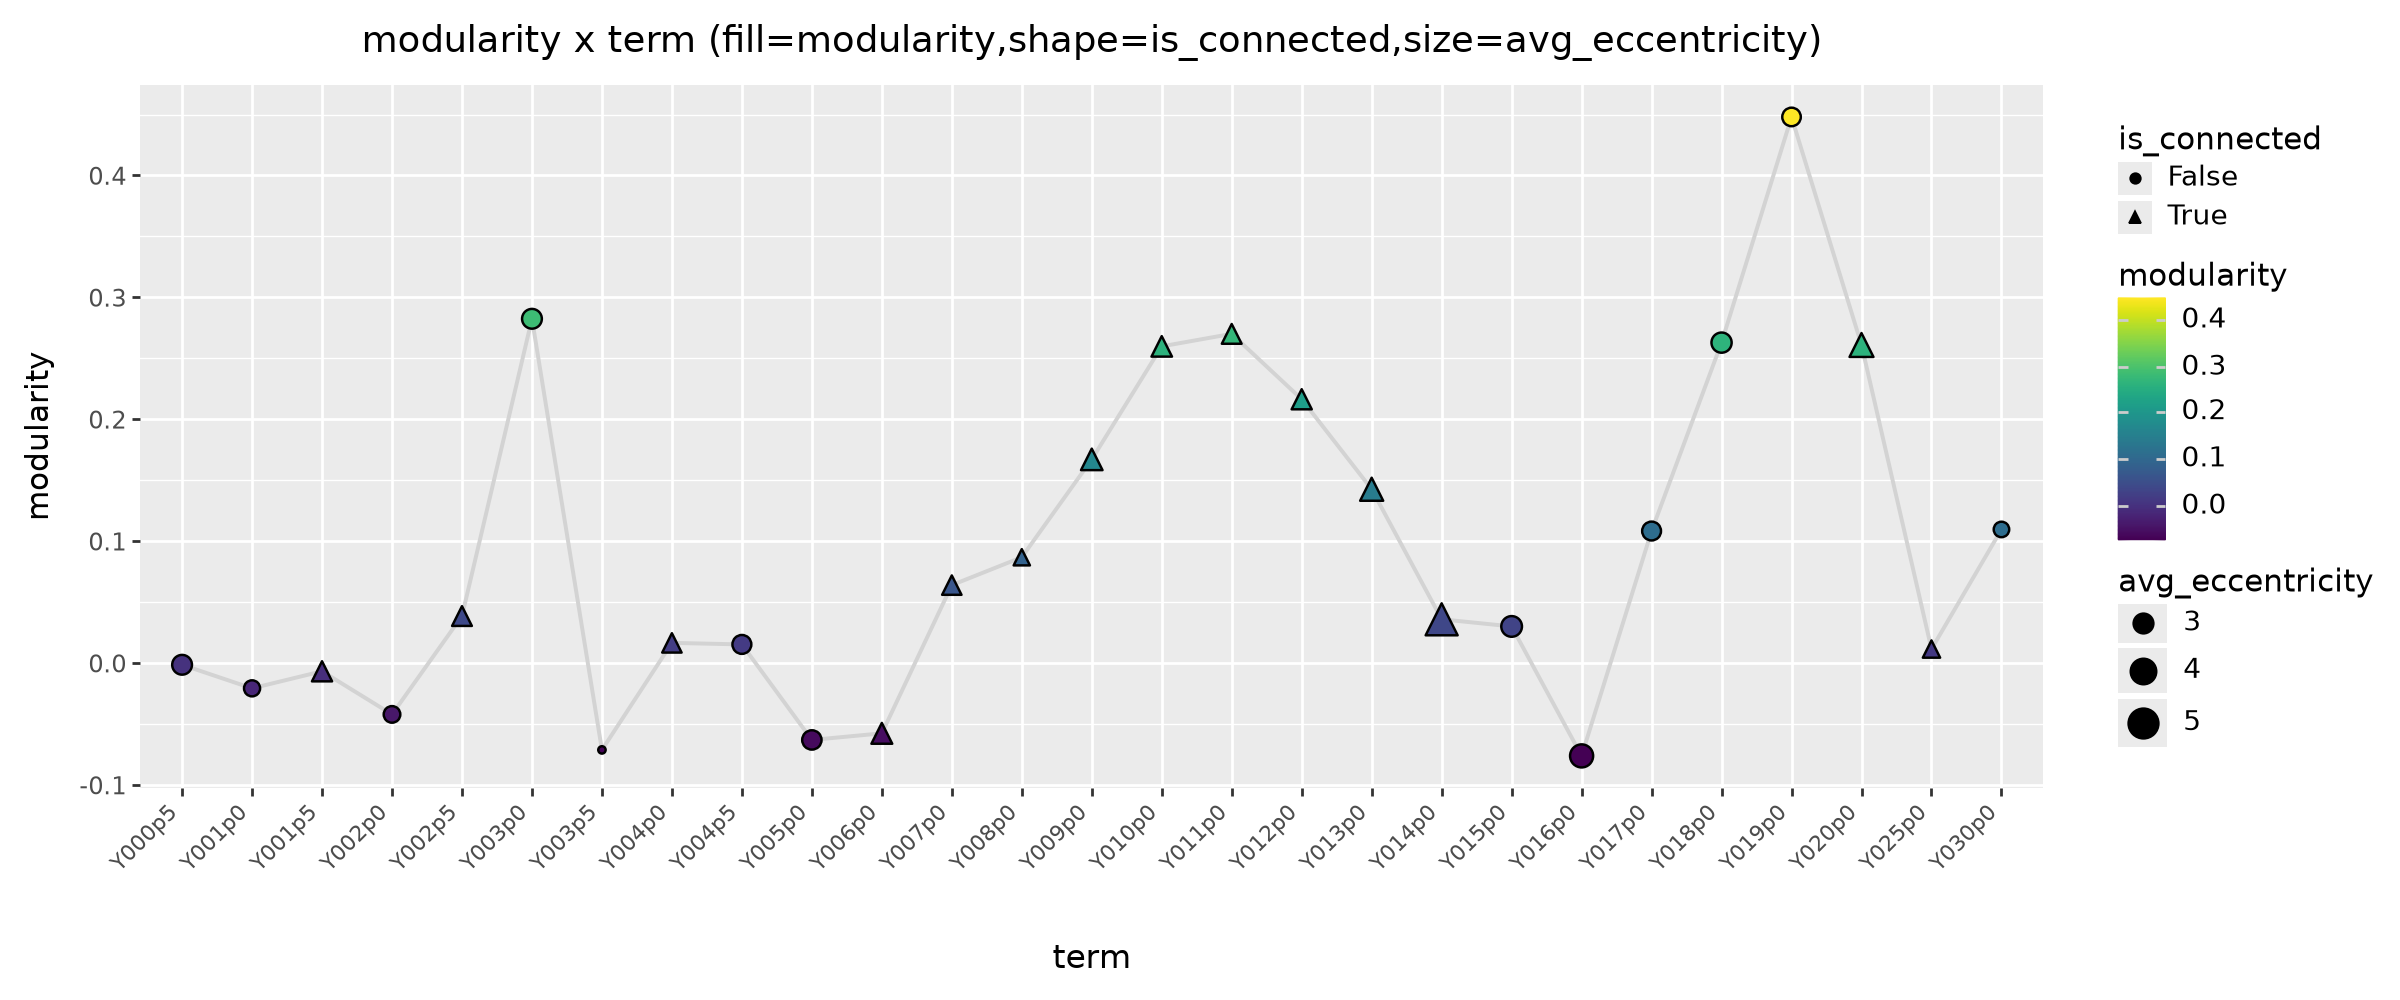

In [127]:
import pandas as pd

plot_df = df_residual_network_metrics.sort("term").to_pandas()
plot_df["term"] = pd.Categorical(plot_df["term"], categories=term_cols, ordered=True)

x_axis_name = "term"
# y_axis_name = "n_edges"
y_axis_name = "modularity"
# y_axis_name = "n_triangles"
shape_name = "is_connected"
fill_name = "modularity"
point_size_name = "avg_eccentricity"

(
    ggplot(plot_df, aes(x=x_axis_name, y=y_axis_name, shape=shape_name, fill=fill_name))
    + geom_line(aes(group=1), color="lightgray", size=0.8)
    + geom_point(aes(size=point_size_name))
    + ggtitle(f"{y_axis_name} x {x_axis_name} (fill={fill_name},shape={shape_name},size={point_size_name})")
    + theme(
        axis_text_x=element_text(size=8, angle=45, ha="right"),
        axis_title_x=element_text(size=12, margin={"t": 10}),
        legend_position="right",
        legend_text=element_text(size=10),
        legend_title=element_text(size=11),
        legend_key_size=12,
        figure_size=(12, 5),
    )
)


## Chapter J: Temporal Dynamics & Factor Evolution

Track how yield curve factors evolve over time; identify regime changes.

### Factor trajectories


In [128]:
# Compute factor trajectories over time
factor_stats = compute_factor_trajectories(ns_market, window_size=30, step_size=10)

# Convert to DataFrame for visualization
factor_evolution = pl.DataFrame({
    'window_idx': np.arange(len(factor_stats['windows'])),
    'date_end': [w[1] for w in factor_stats['windows']],
    'level_mean': factor_stats['level_mean'],
    'level_std': factor_stats['level_std'],
    'slope_mean': factor_stats['slope_mean'],
    'slope_std': factor_stats['slope_std'],
    'curvature_mean': factor_stats['curvature_mean'],
    'curvature_std': factor_stats['curvature_std'],
})

print("Factor evolution over time:")
print(factor_evolution.head(10))

Factor evolution over time:
shape: (10, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ window_idx ┆ date_end   ┆ level_mean ┆ level_std ┆ slope_mea ┆ slope_std ┆ curvature ┆ curvature │
│ ---        ┆ ---        ┆ ---        ┆ ---       ┆ n         ┆ ---       ┆ _mean     ┆ _std      │
│ i64        ┆ str        ┆ f64        ┆ f64       ┆ ---       ┆ f64       ┆ ---       ┆ ---       │
│            ┆            ┆            ┆           ┆ f64       ┆           ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0          ┆ 1990-02-12 ┆ 8.713473   ┆ 0.186952  ┆ 2.670278  ┆ 0.62695   ┆ 2.100388  ┆ 0.747377  │
│ 1          ┆ 1990-02-26 ┆ 8.876656   ┆ 0.186235  ┆ 2.420829  ┆ 0.519163  ┆ 2.542288  ┆ 0.641892  │
│ 2          ┆ 1990-03-12 ┆ 9.016461   ┆ 0.22364   ┆ 2.130135  ┆ 0.622205  ┆ 2.902096  ┆ 0.809987  │
│ 3          ┆ 1990-03-26 ┆ 9.167134   ┆ 0.18333

### Regime classification (Gaussian mixture)


In [153]:
# Regime classification via Gaussian Mixture Model
factors_array = ns_market.select(['level', 'slope', 'curvature']).to_numpy()
regimes = classify_yield_curve_regimes(factors_array, n_regimes=3)

# Add regime to NS dataframe
ns_market_with_regimes = ns_market.with_columns(
    regime=pl.Series(regimes.regime_labels)
)

print(f"Identified {len(np.unique(regimes.regime_labels))} yield curve regimes:")
for i, name in enumerate(regimes.regime_names):
    count = np.sum(regimes.regime_labels == i)
    print(f"  {name}: {count} observations")
    print(f"    Mean factors: {regimes.regime_means[i]}")

Identified 3 yield curve regimes:
  Inverted: 7732 observations
    Mean factors: [ 4.55699601 -1.1447399  -2.7828787 ]
  Inverted: 1209 observations
    Mean factors: [ 8.72106856 -1.56331727 -0.69424661]
  Steep: 791 observations
    Mean factors: [ 5.36929003  0.55179227 -1.00004186]


### Factor evolution plots (plotnine)


In [154]:
# Visualize factor evolution and regime transitions (plotnine)
import pandas as pd
from plotnine import (
    ggplot,
    aes,
    geom_rect,
    geom_line,
    geom_point,
    facet_grid,
    labs,
    theme,
    theme_bw,
    scale_fill_manual,
    scale_x_datetime,
    element_text,
    element_blank,
)

FACTOR_LABELS = {
    "level_mean": "Level",
    "slope_mean": "Slope",
    "curvature_mean": "Curvature",
}
FACTOR_STD_LABELS = {
    "level_std": "Level",
    "slope_std": "Slope",
    "curvature_std": "Curvature",
}
FACTOR_ORDER = ["Level", "Slope", "Curvature"]
REGIME_COLORS = {
    name: color
    for name, color in zip(
        regimes.regime_names,
        ["#0ea5e9", "#a78bfa", "#34d399"],
    )
}

# x_axis_name = "window_idx"
x_axis_name = "date_end"

plot_df = (
    factor_evolution.select([x_axis_name, *FACTOR_LABELS.keys()])
    .unpivot(index=x_axis_name, variable_name="factor", value_name="value")
    .with_columns(pl.col("factor").replace_strict(FACTOR_LABELS))
    .to_pandas()
)
plot_df["factor"] = pd.Categorical(
    plot_df["factor"], categories=FACTOR_ORDER, ordered=True
)
plot_df = plot_df.sort_values(["factor", x_axis_name])

plot_df_std = (
    factor_evolution.select([x_axis_name, *FACTOR_STD_LABELS.keys()])
    .unpivot(index=x_axis_name, variable_name="factor", value_name="value")
    .with_columns(pl.col("factor").replace_strict(FACTOR_STD_LABELS))
    .to_pandas()
)
plot_df_std["factor"] = pd.Categorical(
    plot_df_std["factor"], categories=FACTOR_ORDER, ordered=True
)
plot_df_std = plot_df_std.sort_values(["factor", x_axis_name])

if x_axis_name == "date_end":
    plot_df[x_axis_name] = pd.to_datetime(plot_df[x_axis_name])
    plot_df_std[x_axis_name] = pd.to_datetime(plot_df_std[x_axis_name])


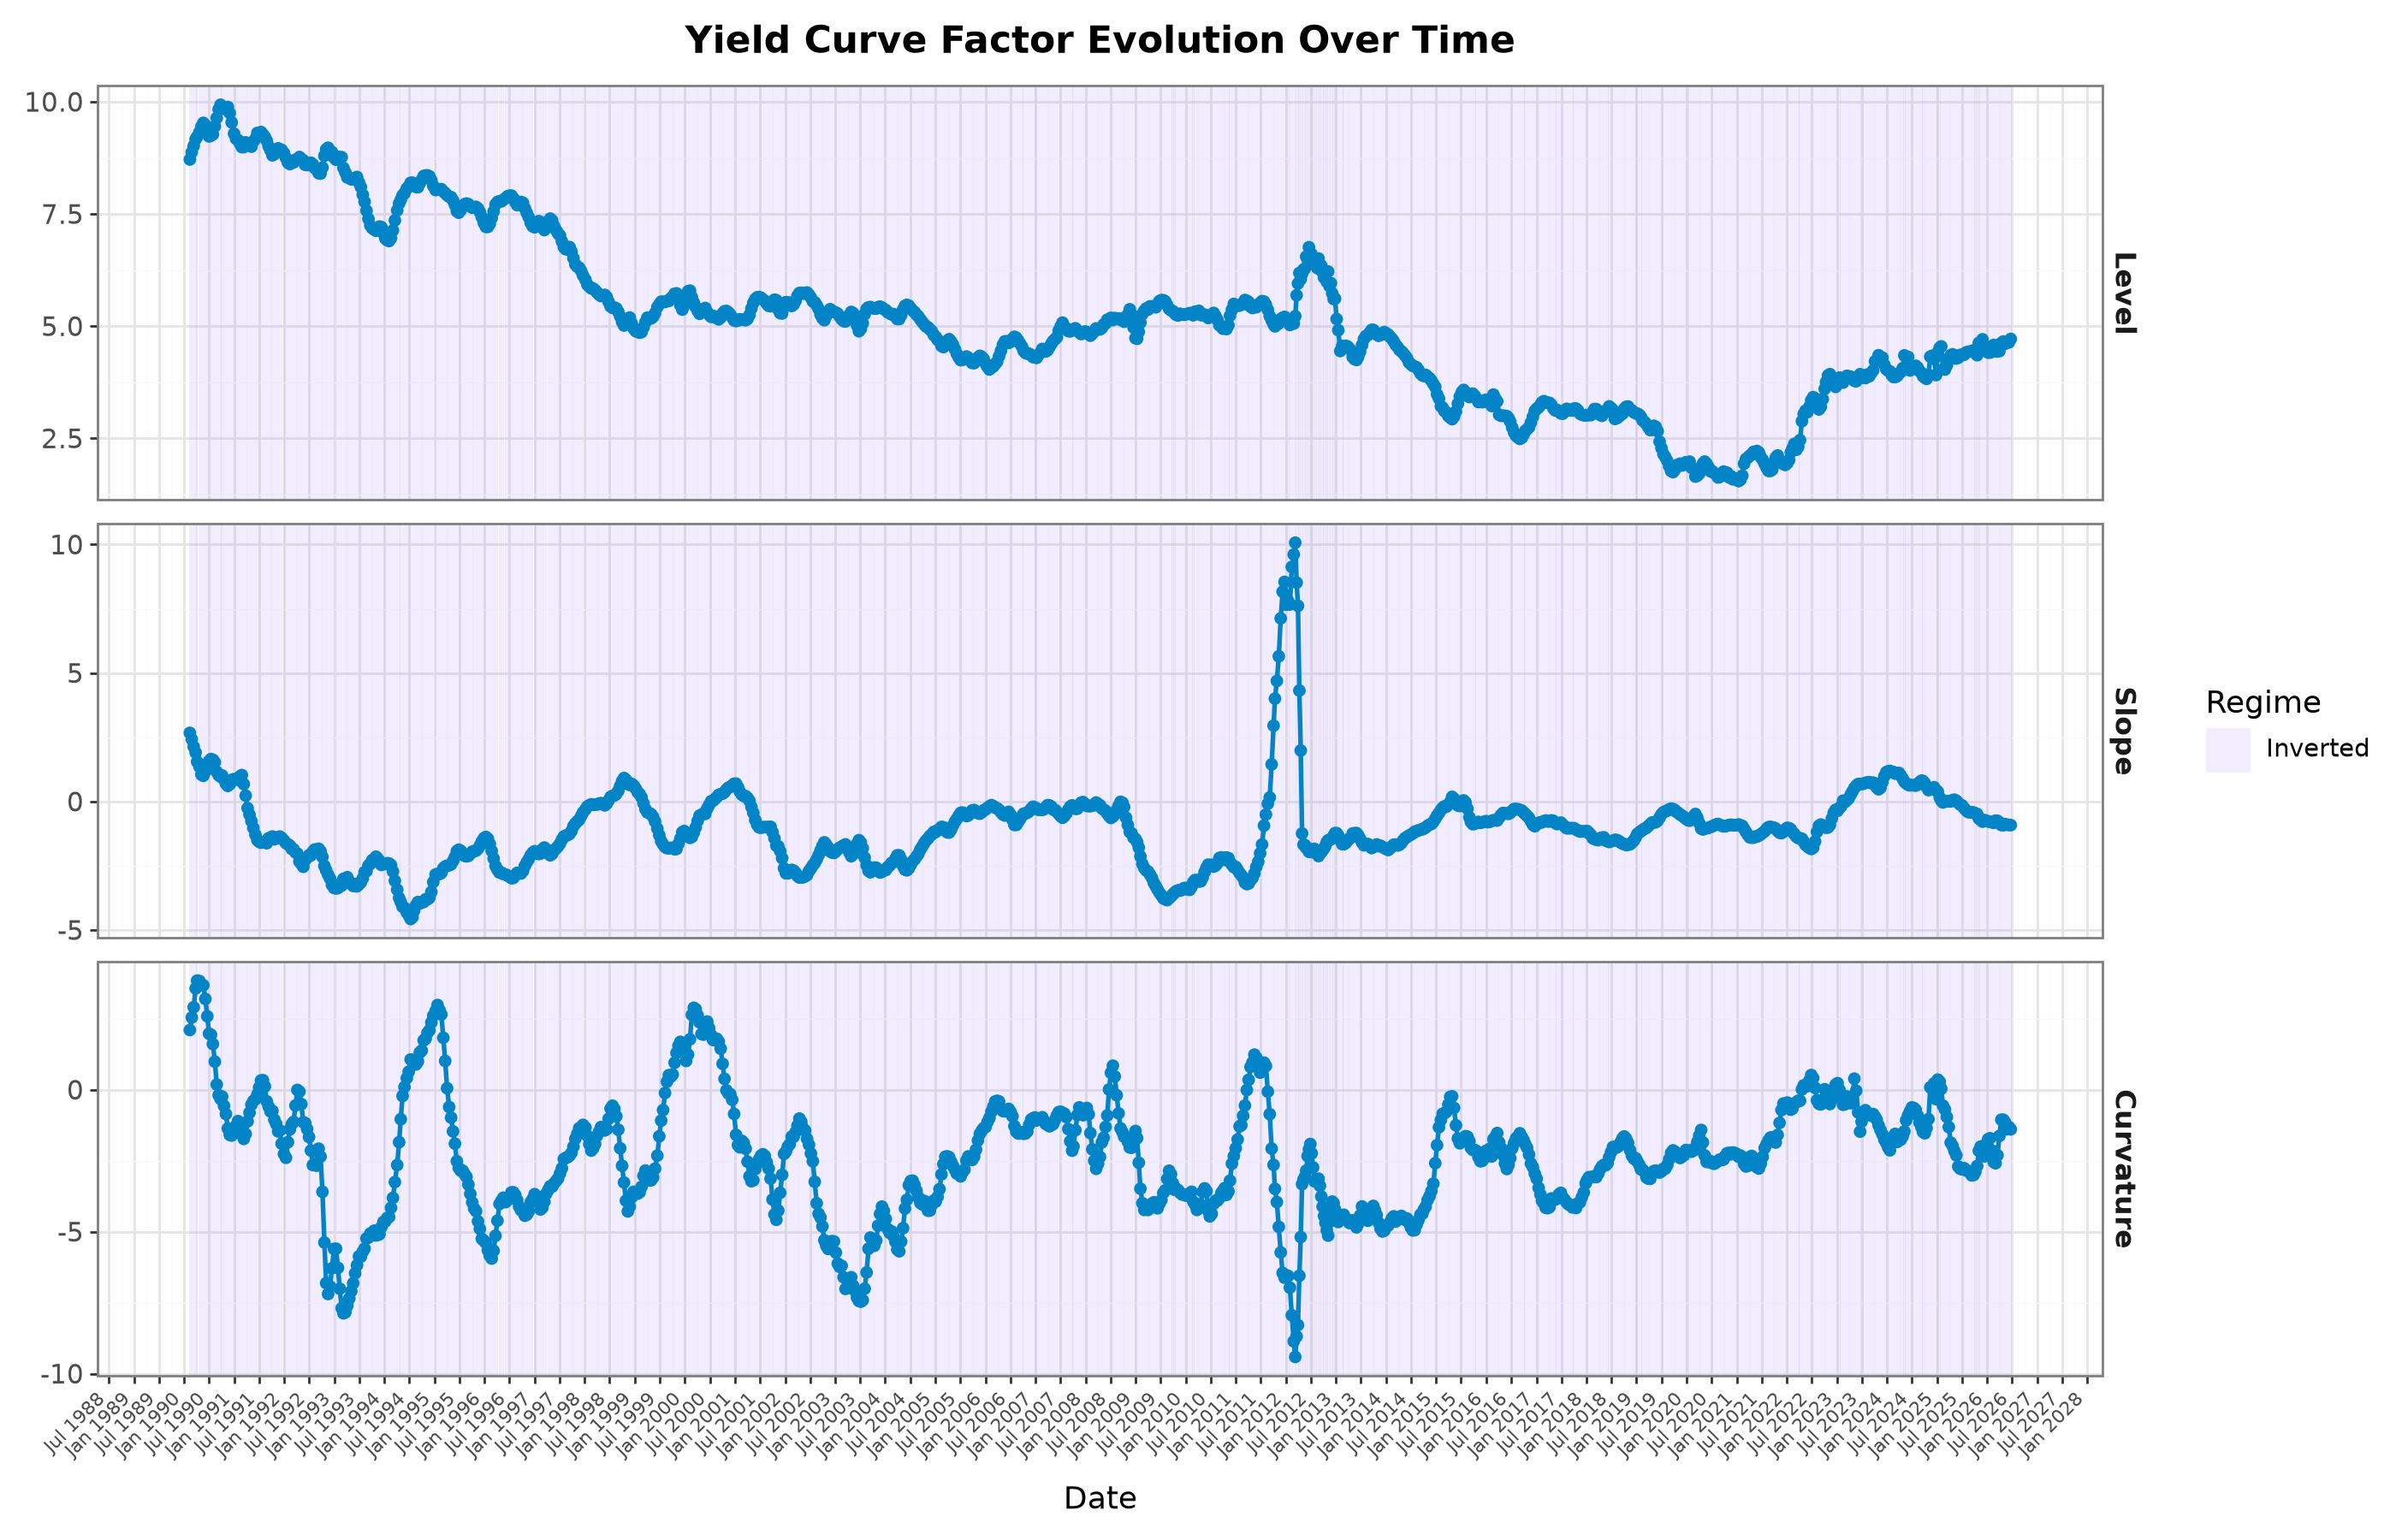

In [155]:
n_windows = int(factor_evolution.height)
n_regimes = len(regimes.regime_labels)
regime_at_window = [
    regimes.regime_names[int(regimes.regime_labels[min(i, n_regimes - 1)])]
    for i in range(n_windows)
]

if x_axis_name == "date_end":
    window_x = pd.to_datetime(factor_evolution["date_end"].to_pandas())
    half_step = (
        (window_x.iloc[1] - window_x.iloc[0]) / 2
        if len(window_x) > 1
        else pd.Timedelta(days=5)
    )
    band_x = {"xmin": window_x - half_step, "xmax": window_x + half_step}
    x_label = "Date"
else:
    band_x = {
        "xmin": np.arange(n_windows) - 0.5,
        "xmax": np.arange(n_windows) + 0.5,
    }
    x_label = "Window Index"

bands = pd.concat(
    [
        pd.DataFrame(
            {
                **band_x,
                "regime": regime_at_window,
                "factor": factor_name,
            }
        )
        for factor_name in FACTOR_ORDER
    ],
    ignore_index=True,
)
bands["factor"] = pd.Categorical(
    bands["factor"], categories=FACTOR_ORDER, ordered=True
)

factor_plot = (
    ggplot(plot_df, aes(x_axis_name, "value"))
    + geom_rect(
        aes(
            xmin="xmin",
            xmax="xmax",
            ymin=float("-inf"),
            ymax=float("inf"),
            fill="regime",
        ),
        data=bands,
        alpha=0.15,
        inherit_aes=False,
    )
    + geom_line(size=1.1, color="#0284c7")
    + geom_point(size=2, color="#0284c7")
    + facet_grid("factor ~ .", scales="free_y")
    + scale_fill_manual(values=REGIME_COLORS)
)

if x_axis_name == "date_end":
    factor_plot = factor_plot + scale_x_datetime(
        date_breaks="6 months", date_labels="%b %Y"
    )

factor_plot = (
    factor_plot
    + labs(
        title="Yield Curve Factor Evolution Over Time",
        x=x_label,
        y="",
        fill="Regime",
    )
    + theme_bw(base_size=13)
    + theme(
        figure_size=(14, 9),
        plot_title=element_text(size=16, weight="bold", ha="center"),
        strip_text=element_text(size=12, weight="bold"),
        strip_background=element_blank(),
        axis_text=element_text(size=11),
        axis_text_x=element_text(size=8, angle=45, ha="right"),
    )
)
factor_plot.save("factor_evolution.png", dpi=150, width=14, height=9, verbose=False)
factor_plot


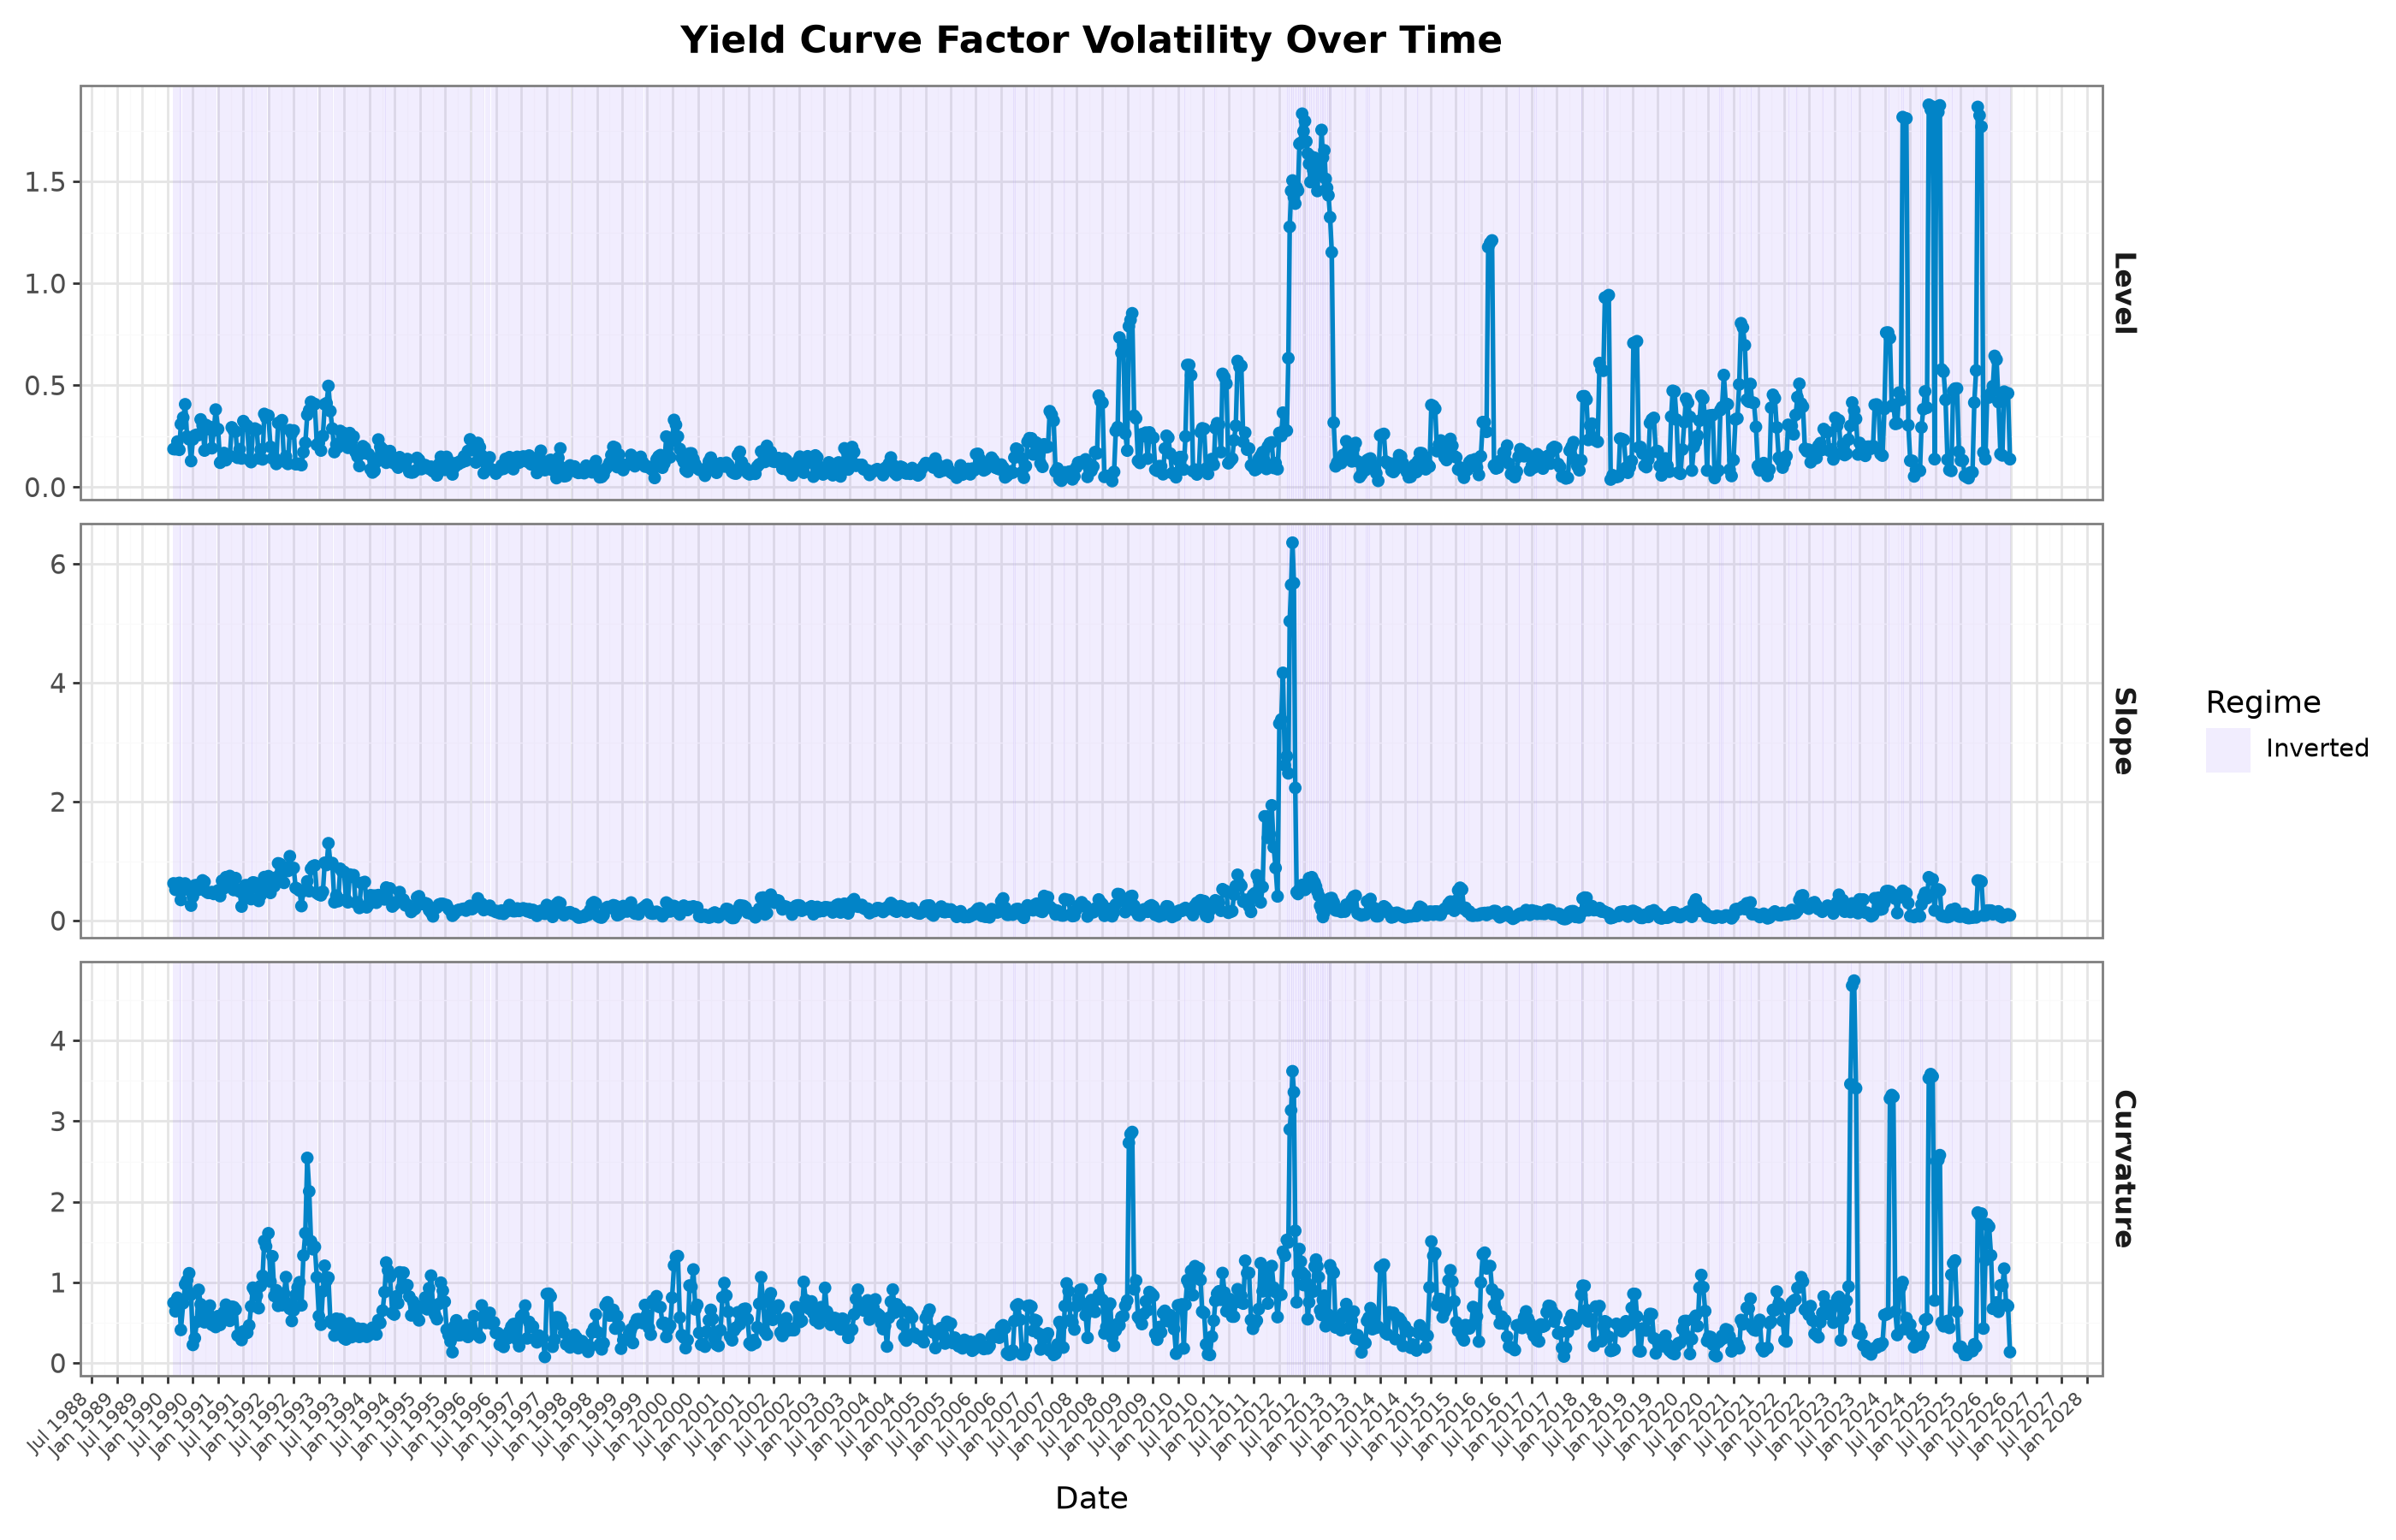

In [156]:
factor_std_plot = (
    ggplot(plot_df_std, aes(x_axis_name, "value"))
    + geom_rect(
        aes(
            xmin="xmin",
            xmax="xmax",
            ymin=float("-inf"),
            ymax=float("inf"),
            fill="regime",
        ),
        data=bands,
        alpha=0.15,
        inherit_aes=False,
    )
    + geom_line(size=1.1, color="#0284c7")
    + geom_point(size=2, color="#0284c7")
    + facet_grid("factor ~ .", scales="free_y")
    + scale_fill_manual(values=REGIME_COLORS)
)
if x_axis_name == "date_end":
    factor_std_plot = factor_std_plot + scale_x_datetime(
        date_breaks="6 months", date_labels="%b %Y"
    )

factor_std_plot = (
    factor_std_plot
    + labs(
        title="Yield Curve Factor Volatility Over Time",
        x=x_label,
        y="",
        fill="Regime",
    )
    + theme_bw(base_size=13)
    + theme(
        figure_size=(14, 9),
        plot_title=element_text(size=16, weight="bold", ha="center"),
        strip_text=element_text(size=12, weight="bold"),
        strip_background=element_blank(),
        axis_text=element_text(size=11),
        axis_text_x=element_text(size=8, angle=45, ha="right"),
    )
)
factor_std_plot.save(
    "factor_volatility_evolution.png", dpi=150, width=14, height=9, verbose=False
)
factor_std_plot


In [150]:
factor_evolution

window_idx,date_end,level_mean,level_std,slope_mean,slope_std,curvature_mean,curvature_std
i64,str,f64,f64,f64,f64,f64,f64
0,"""1990-02-12""",8.713473,0.186952,2.670278,0.62695,2.100388,0.747377
1,"""1990-02-26""",8.876656,0.186235,2.420829,0.519163,2.542288,0.641892
2,"""1990-03-12""",9.016461,0.22364,2.130135,0.622205,2.902096,0.809987
3,"""1990-03-26""",9.167134,0.183336,1.902891,0.635179,3.565423,0.78532
4,"""1990-04-06""",9.219337,0.309347,1.551474,0.347955,3.841034,0.411048
…,…,…,…,…,…,…,…
966,"""2026-04-28""",4.657222,0.155638,-0.925937,0.05893,-1.056505,0.960801
967,"""2026-05-11""",4.606421,0.468828,-0.882548,0.081553,-1.141511,1.171554
968,"""2026-05-25""",4.633307,0.458093,-0.906873,0.098537,-1.394438,0.725375


## Chapter K: Stress Testing & Correlation Breakdown

Detect market stress through correlation matrix changes and liquidity indicators.

### Rolling correlation stability


In [160]:
# Compute rolling correlation matrices across windows; detect breakdowns
def compute_correlation_stability(
    cube: np.ndarray,
    window_size: int = 30,
    step_size: int = 10,
) -> dict:
    """Detect correlation stability over rolling windows on an aligned cube."""
    n_sources, n_dates, n_terms = cube.shape
    term_idx = n_terms // 2
    stability_metrics = {
        "windows": [],
        "avg_abs_correlation": [],
        "correlation_variance": [],
        "n_significant_edges": [],
    }

    for w_start in range(0, n_dates - window_size + 1, step_size):
        w_end = w_start + window_size
        ts = cube[:, w_start:w_end, term_idx]
        ts = ts[:, ~np.isnan(ts).any(axis=0)]
        if ts.shape[1] <= 1:
            continue
        corr_matrix = np.corrcoef(ts)
        abs_corr = np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)])
        stability_metrics["windows"].append((w_start, w_end))
        stability_metrics["avg_abs_correlation"].append(float(np.mean(abs_corr)))
        stability_metrics["correlation_variance"].append(float(np.var(abs_corr)))
        stability_metrics["n_significant_edges"].append(int(np.sum(abs_corr > 0.5)))

    return stability_metrics


stress_metrics = compute_correlation_stability(residual_cube, window_size=30, step_size=10)

stress_df = pl.DataFrame({
    "window_idx": np.arange(len(stress_metrics["windows"])),
    "date_end": [residual_dates[w[1] - 1] for w in stress_metrics["windows"]],
    "avg_abs_corr": stress_metrics["avg_abs_correlation"],
    "corr_variance": stress_metrics["correlation_variance"],
    "n_sig_edges": stress_metrics["n_significant_edges"],
})

print("Correlation stability metrics:")
print(stress_df.head(15))


Correlation stability metrics:
shape: (15, 5)
┌────────────┬────────────┬──────────────┬───────────────┬─────────────┐
│ window_idx ┆ date_end   ┆ avg_abs_corr ┆ corr_variance ┆ n_sig_edges │
│ ---        ┆ ---        ┆ ---          ┆ ---           ┆ ---         │
│ i64        ┆ str        ┆ f64          ┆ f64           ┆ i64         │
╞════════════╪════════════╪══════════════╪═══════════════╪═════════════╡
│ 0          ┆ 2013-03-04 ┆ 0.352737     ┆ 0.049641      ┆ 46          │
│ 1          ┆ 2013-03-19 ┆ 0.449178     ┆ 0.061212      ┆ 70          │
│ 2          ┆ 2013-04-09 ┆ 0.441545     ┆ 0.068402      ┆ 75          │
│ 3          ┆ 2013-04-23 ┆ 0.468146     ┆ 0.067008      ┆ 81          │
│ 4          ┆ 2013-05-16 ┆ 0.381683     ┆ 0.051181      ┆ 56          │
│ …          ┆ …          ┆ …            ┆ …             ┆ …           │
│ 10         ┆ 2013-08-27 ┆ 0.448889     ┆ 0.076856      ┆ 74          │
│ 11         ┆ 2013-09-11 ┆ 0.393447     ┆ 0.075178      ┆ 54          │
│ 12 

### Stress-indicator plots (plotnine)


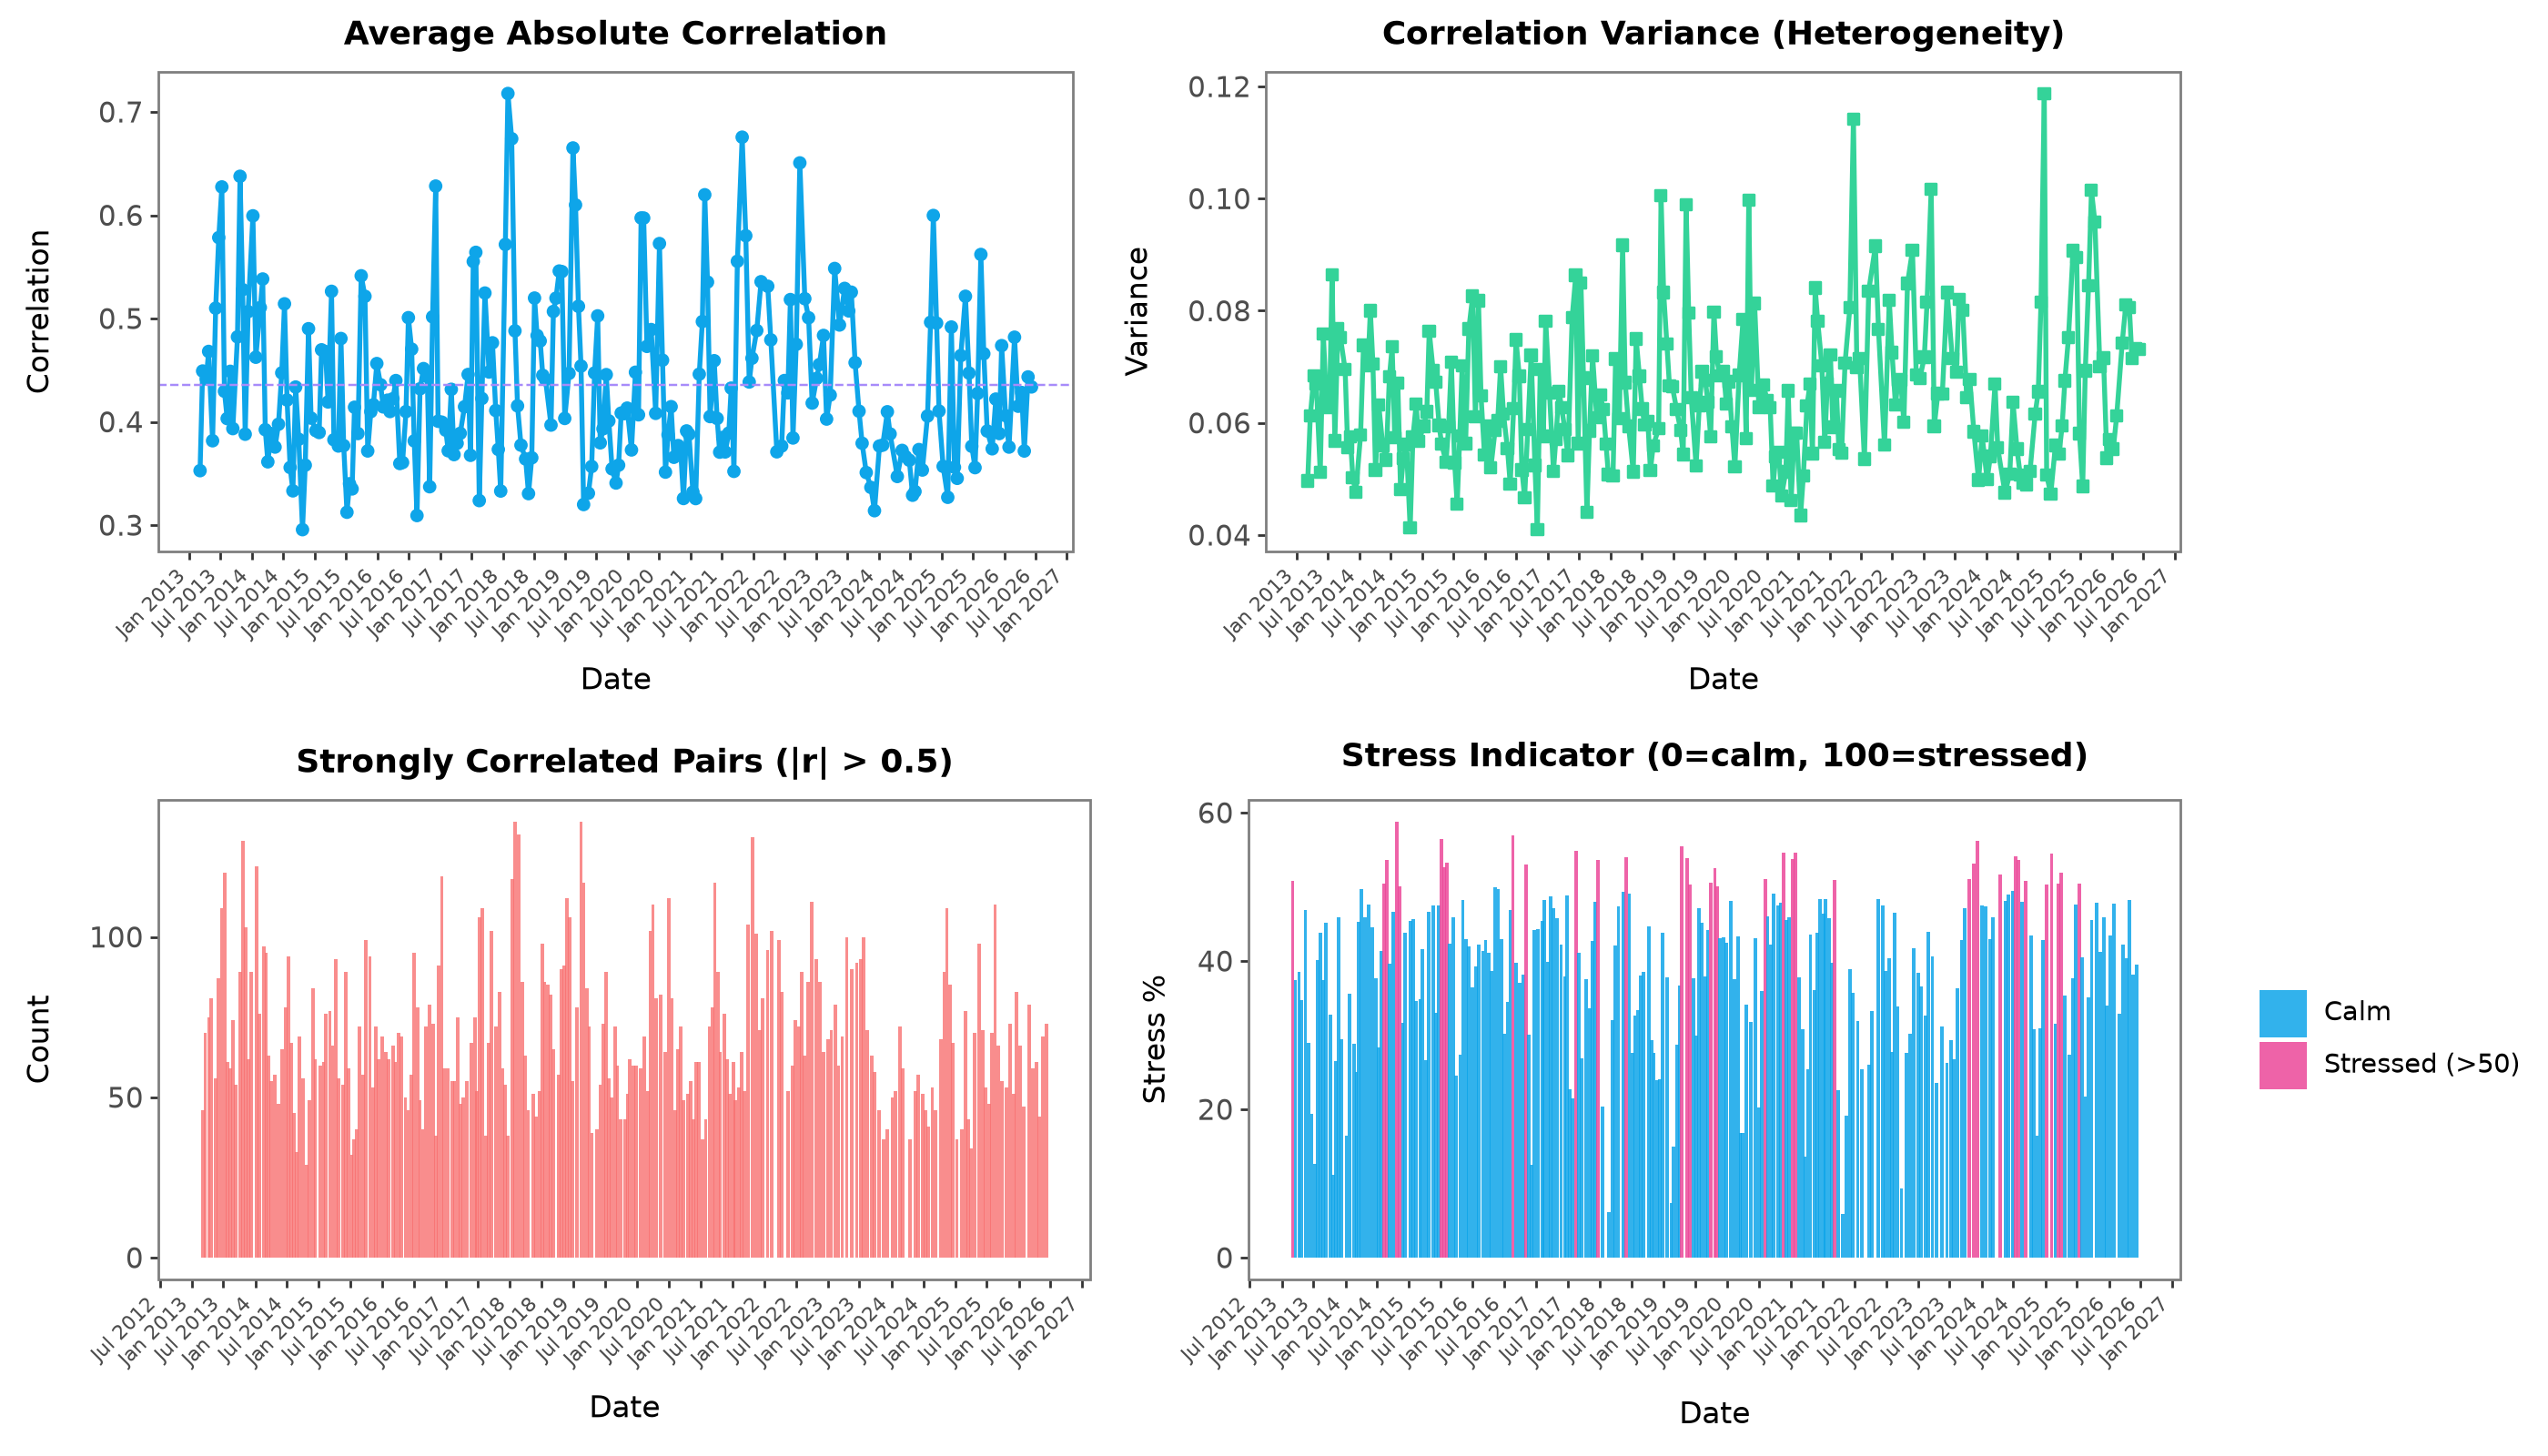

In [161]:
# Visualize stress indicators (plotnine)
import pandas as pd
from plotnine import (
    ggplot,
    aes,
    geom_line,
    geom_point,
    geom_col,
    geom_hline,
    labs,
    theme,
    theme_bw,
    scale_fill_manual,
    scale_x_datetime,
    element_text,
    element_blank,
)

stress_x = "date_end"

stress_plot_df = stress_df.with_columns(
    (
        (1.0 - pl.col("avg_abs_corr") / pl.col("avg_abs_corr").max()) * 100.0
    ).alias("stress_pct")
).to_pandas()
stress_plot_df[stress_x] = pd.to_datetime(stress_plot_df[stress_x])
mean_corr = float(stress_df["avg_abs_corr"].mean())
stress_plot_df["stress_band"] = np.where(
    stress_plot_df["stress_pct"] > 50.0, "Stressed (>50)", "Calm"
)

_x_scale = scale_x_datetime(date_breaks="6 months", date_labels="%b %Y")

_panel_theme = theme_bw(base_size=13) + theme(
    plot_title=element_text(size=13, weight="bold"),
    axis_text=element_text(size=11),
    axis_title=element_text(size=12),
    axis_text_x=element_text(size=8, angle=45, ha="right"),
    legend_title=element_blank(),
    panel_grid_major=element_blank(),
    panel_grid_minor=element_blank(),
)

p_avg_corr = (
    ggplot(stress_plot_df, aes(stress_x, "avg_abs_corr"))
    + geom_line(size=1.1, color="#0ea5e9")
    + geom_point(size=2, color="#0ea5e9")
    + geom_hline(yintercept=mean_corr, linetype="dashed", color="#a78bfa")
    + _x_scale
    + labs(title="Average Absolute Correlation", x="Date", y="Correlation")
    + _panel_theme
)

p_var = (
    ggplot(stress_plot_df, aes(stress_x, "corr_variance"))
    + geom_line(size=1.1, color="#34d399")
    + geom_point(shape="s", size=2, color="#34d399")
    + _x_scale
    + labs(title="Correlation Variance (Heterogeneity)", x="Date", y="Variance")
    + _panel_theme
)

p_edges = (
    ggplot(stress_plot_df, aes(stress_x, "n_sig_edges"))
    + geom_col(fill="#f87171", alpha=0.8, width=20)
    + _x_scale
    + labs(
        title="Strongly Correlated Pairs (|r| > 0.5)",
        x="Date",
        y="Count",
    )
    + _panel_theme
)

p_stress = (
    ggplot(stress_plot_df, aes(stress_x, "stress_pct", fill="stress_band"))
    + geom_col(alpha=0.85, width=20)
    + scale_fill_manual(values={"Calm": "#0ea5e9", "Stressed (>50)": "#ec4899"})
    + _x_scale
    + labs(
        title="Stress Indicator (0=calm, 100=stressed)",
        x="Date",
        y="Stress %",
        fill="",
    )
    + _panel_theme
)

stress_plot = ((p_avg_corr | p_var) / (p_edges | p_stress)) + theme(
    figure_size=(14, 8)
)
stress_plot.save("stress_detection.png", dpi=150, width=14, height=8, verbose=False)
stress_plot


## Chapter L: Advanced Centrality & Network Influence

Compute centrality accounting for multi-layer structure and spreading dynamics.

### Multi-layer degree centrality (residual graphs)


In [ ]:
# Multi-layer centrality: mean per-layer score across maturity terms
from ycn.analysis.evolution import _add_strength_attr, _node_centrality

CENTRALITY_MEASURES = ("degree", "betweenness", "eigenvector")


def compute_multilayer_centrality(
    layer_graphs: dict[str, nx.Graph],
    measure: str = "degree",
) -> dict[str, float]:
    """Mean per-layer centrality for each issuer across layers.

    Args:
        layer_graphs: Layer name -> graph (e.g. term -> residual network).
        measure: ``degree``, ``betweenness``, or ``eigenvector``.

    Returns:
        Issuer -> mean centrality across layers.
    """
    if measure not in CENTRALITY_MEASURES:
        raise ValueError(
            f"Unknown measure {measure!r}; choose from {CENTRALITY_MEASURES}"
        )
    all_nodes = sorted({n for g in layer_graphs.values() for n in g.nodes()})
    totals = dict.fromkeys(all_nodes, 0.0)
    n_layers = len(layer_graphs) or 1
    for graph in layer_graphs.values():
        if graph.number_of_nodes() == 0:
            continue
        g = graph.copy()
        _add_strength_attr(g)
        scores = _node_centrality(g, measure)
        for node in all_nodes:
            totals[node] += float(scores.get(node, 0.0))
    return {node: totals[node] / n_layers for node in all_nodes}


def compute_all_multilayer_centralities(
    layer_graphs: dict[str, nx.Graph],
    measures: tuple[str, ...] = CENTRALITY_MEASURES,
) -> dict[str, dict[str, float]]:
    """Compute several centrality measures, each averaged across layers."""
    return {m: compute_multilayer_centrality(layer_graphs, m) for m in measures}

multilayer_centralities = compute_all_multilayer_centralities(residual_networks)

multilayer_centrality_df =  pl.DataFrame(
        [
            {"issuer": issuer, "measure": measure, "centrality": score}
            for measure, scores in multilayer_centralities.items()
            for issuer, score in scores.items()
        ] )
multilayer_centrality_df.tail()


issuer,measure,centrality
str,str,f64
"""KOR""","""eigenvector""",0.249051
"""NLD""","""eigenvector""",0.177438
"""PRT""","""eigenvector""",0.341844
"""RUS""","""eigenvector""",0.06048
"""USA""","""eigenvector""",0.266631


In [190]:
# Mean layer-averaged centrality per issuer (wide: one column per measure)
issuer_centrality_df = (
    multilayer_centrality_df.pivot(
        index="issuer",
        on="measure",
        values="centrality",
    )
    .with_columns(
        pl.mean_horizontal([pl.col(m) for m in CENTRALITY_MEASURES]).alias(
            "mean_centrality"
        )
    )
    .sort("mean_centrality", descending=True)
)
issuer_centrality_df


issuer,degree,betweenness,eigenvector,mean_centrality
str,f64,f64,f64,f64
"""IRL""",0.432099,0.604454,0.324781,0.453778
"""PRT""",0.444444,0.495885,0.341844,0.427391
"""DEU""",0.631687,0.264948,0.262067,0.386234
"""USA""",0.427984,0.444323,0.266631,0.379646
"""JPN""",0.349794,0.428347,0.293705,0.357282
…,…,…,…,…
"""AUS""",0.308642,0.119826,0.154905,0.194458
"""GBR""",0.238683,0.103123,0.122805,0.15487
"""CHN""",0.242798,0.078068,0.129054,0.149974


In [196]:
# Wide: one row per issuer, one column per measure (+ mean across measures)
issuer_centrality_df = (
    multilayer_centrality_df.pivot(
        index="issuer",
        on="measure",
        values="centrality",
    )
    .with_columns(
        pl.mean_horizontal([pl.col(m) for m in CENTRALITY_MEASURES]).alias(
            "mean_centrality"
        )
    )
    .sort("mean_centrality", descending=True)
)

# Long / melted: issuer, measure, centrality
issuer_centrality_long = issuer_centrality_df.unpivot(
    index="issuer",
    on=list(CENTRALITY_MEASURES),
    variable_name="measure",
    value_name="centrality",
).sort(["issuer", "measure"])

issuer_centrality_long


issuer,measure,centrality
str,str,f64
"""AUS""","""betweenness""",0.119826
"""AUS""","""degree""",0.308642
"""AUS""","""eigenvector""",0.154905
"""BEL""","""betweenness""",0.015977
"""BEL""","""degree""",0.528807
…,…,…
"""RUS""","""degree""",0.061728
"""RUS""","""eigenvector""",0.06048
"""USA""","""betweenness""",0.444323


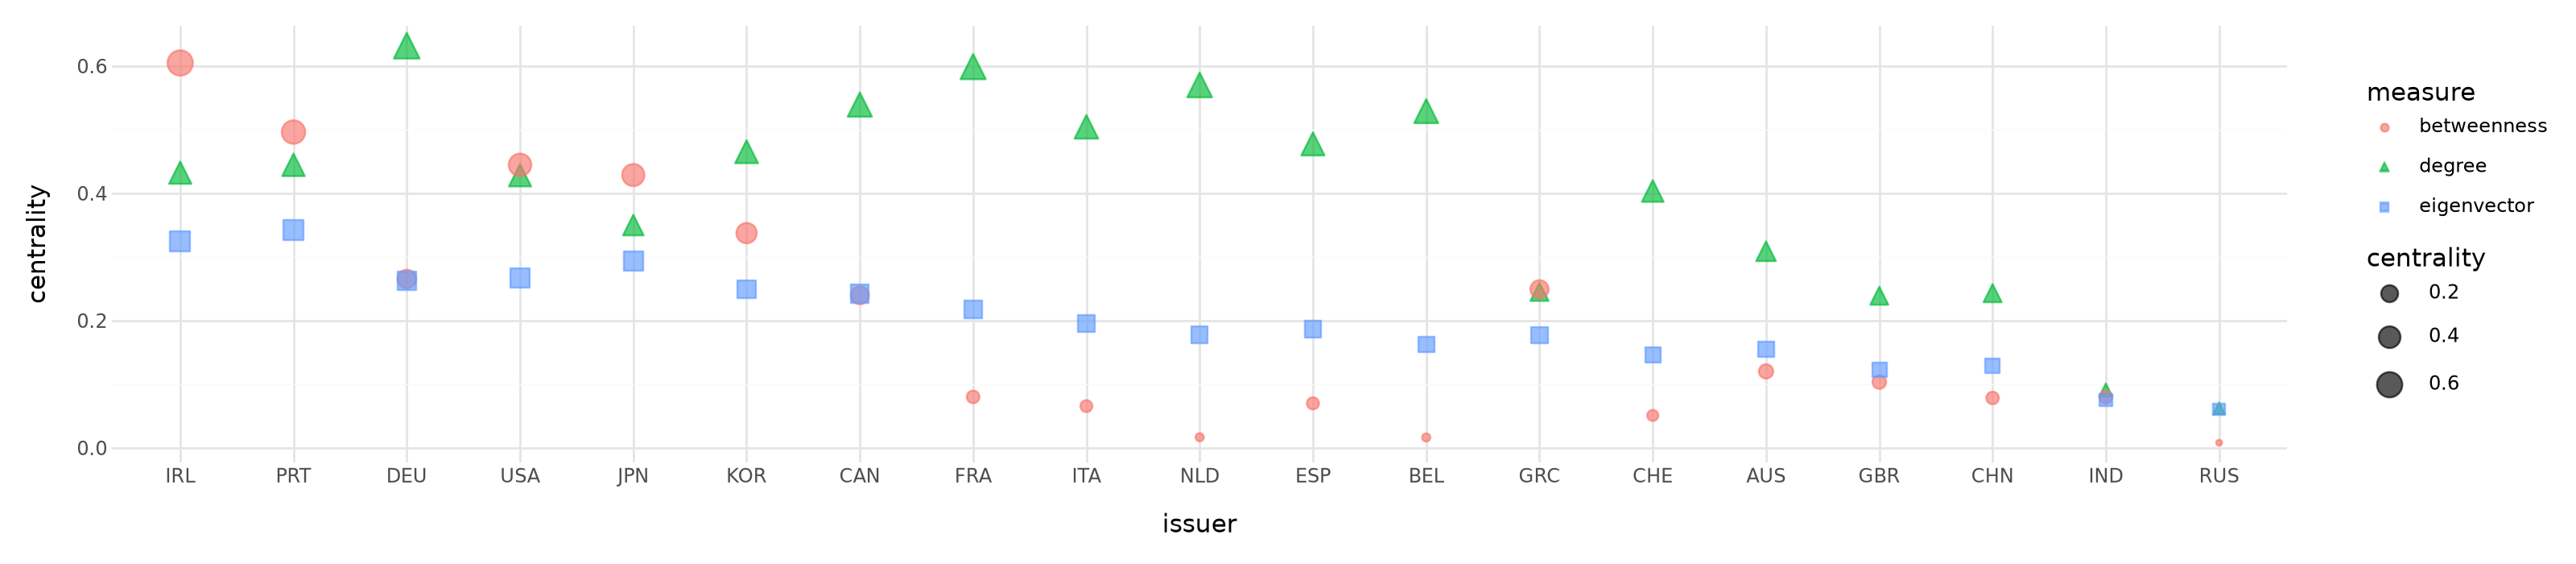

In [198]:
import pandas as pd

issuer_order = issuer_centrality_df.sort("mean_centrality", descending=True)[
    "issuer"
].to_list()

centrality_plot_df = issuer_centrality_long.to_pandas()
centrality_plot_df["issuer"] = pd.Categorical(
    centrality_plot_df["issuer"], categories=issuer_order, ordered=True
)

(
    ggplot(
        centrality_plot_df,
        aes(
            x="issuer",
            y="centrality",
            fill="measure",
            color="measure",
            shape="measure",
            size="centrality",
        ),
    )
    + geom_point(alpha=0.65)
    + theme_minimal()
    + theme(figure_size=(16, 3.5))
)


## Chapter M: 3D Interactive Visualization

Visualize multi-layer network in 3D space (issuer ├ù term ├ù time).

### Interactive network visualization (pyvis)

Column **hue** = issuer (vertical columns share a color). Node **size and brightness** increase from short to long maturities (`Y000p5` → `Y030p0`).

Intra-layer edges (same term, any issuer pair) use **bright blue → white → yellow** and **thickness** for connection strength. They are drawn as **arcs**, so AUS–USA at `Y000p5` appears as a curve along that row — not only between alphabetically adjacent columns. If there is no arc, that pair was below the correlation threshold.

Faint vertical rails are inter-layer links (same issuer, adjacent terms). Hover an edge for the numeric strength; scroll to zoom.


In [ ]:
import base64

from IPython.display import HTML, display

from ycn.analysis.pyvis_plot import multilayer_graph_to_html

multilayer_index = -1
w0_start, w0_end = window_indices[multilayer_index]
html = multilayer_graph_to_html(
    multilayer_networks[multilayer_index],
    title=f"Multi-Layer Network (window {multilayer_index}: {w0_start} → {w0_end})",
    height="900px",
)
encoded = base64.b64encode(html.encode("utf-8")).decode("ascii")
display(
    HTML(
        "<p style='color:#cbd5e1;font-family:Segoe UI,sans-serif;margin:0 0 8px 0'>"
        "Columns = issuers (same hue down a column). Rows = terms, short→long (larger/brighter nodes). "
        "Intra-layer arcs: blue=weak, yellow=strong. Non-adjacent pairs (e.g. AUS–USA) are the long curves in a row. "
        "Hover an edge for strength. Bottom-right: zoom / fit. "
        "Scroll to zoom, drag to pan, hover for node/edge details. "
        "Bottom-right buttons: zoom / fit."
        "</p>"
        f'<iframe src="data:text/html;base64,{encoded}" '
        'width="100%" height="900px" frameborder="0" '
        'style="border:1px solid #334155; background:#0f172a;"></iframe>'
    )
)
